In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from imblearn import over_sampling, under_sampling

import matplotlib.pyplot as plt

%matplotlib Inline
%config IlineBackend.figure_format = "svg"

In [3]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

## EDA (Exploratory Data Analysis)

### Target variable and base statistics

In [41]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  10000 non-null  float64
 1   years_of_experience  10000 non-null  float64
 2   lesson_price         10000 non-null  float64
 3   qualification        10000 non-null  float64
 4   physics              10000 non-null  float64
 5   chemistry            10000 non-null  float64
 6   biology              10000 non-null  float64
 7   english              10000 non-null  float64
 8   geography            10000 non-null  float64
 9   history              10000 non-null  float64
 10  mean_exam_points     10000 non-null  float64
 11  choose               10000 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 937.6 KB


* **Id** - unique identifier
* **age** - Age of tutor
* **years_of_experience**
* **lesson_price**
* **qualification**
* **physics** - teaches physics
* **chemistry** - teaches chemistry
* **biology** - teaches biology
* **english** - teaches english
* **geography** - teaches geography
* **history** - teaches history
* **mean_exam_points**
* **choose** - target

In [42]:
df_train.describe()

,age,years_of_experience,lesson_price,qualification,physics,chemistry,biology,english,geography,history,mean_exam_points,choose
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,45.800900,1.974800,1702.440000,1.724300,0.37060,0.121500,0.117200,0.059100,0.02770,0.018000,64.435200,0.110900
std,8.030274,1.766883,523.789062,0.798845,0.48299,0.326724,0.321675,0.235824,0.16412,0.132958,13.595024,0.314024
min,23.000000,0.000000,200.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,33.000000,0.000000
25%,40.000000,0.000000,1300.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,55.000000,0.000000
50%,46.000000,2.000000,1550.000000,2.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,63.000000,0.000000
75%,51.000000,3.000000,2150.000000,2.000000,1.00000,0.000000,0.000000,0.000000,0.00000,0.000000,74.000000,0.000000
max,68.000000,9.000000,3950.000000,4.000000,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000,100.000000,1.000000


At first sight everything is clear. There are no Null elements in features, min and max values apear to be right (no outliers in the data). There are only two types of data. First is int64 type float64. Should think about reducing memory usage.


Continue investigate the data.

In [43]:
df_train.head()

,age,years_of_experience,lesson_price,qualification,physics,chemistry,biology,english,geography,history,mean_exam_points,choose
0,35.0,0.0,2150.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,74.0,0
1,52.0,2.0,1250.0,2.0,1.0,0.0,1.0,0.0,0.0,1.0,57.0,1
2,29.0,3.0,1750.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,66.0,0
3,33.0,3.0,1050.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,66.0,1
4,46.0,3.0,2250.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,73.0,0


In [44]:
df_test.head()

,age,years_of_experience,lesson_price,qualification,physics,chemistry,biology,english,geography,history,mean_exam_points
0,32.0,2.0,2700.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,90.0
1,35.0,6.0,1800.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,71.0
2,44.0,2.0,1200.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0
3,44.0,4.0,2950.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,92.0
4,38.0,3.0,1400.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,58.0


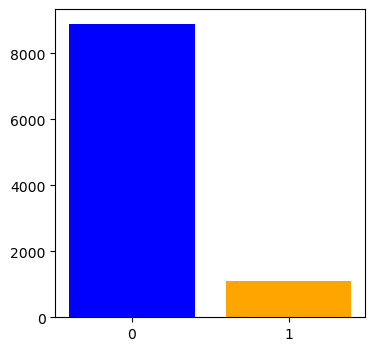

In [155]:
plt.figure(figsize=(4, 4))

target_data = df_train["choose"].value_counts()

plt.bar(target_data.index, target_data.values, color=["blue", "orange"])
plt.xticks(ticks=[0, 1])

plt.show()

There is a big disbalance in the target variable

In [4]:
# Field ID is not informative, let's get rid of it
df_train.drop("Id", axis=1, inplace=True)
df_test.drop("Id", axis=1, inplace=True)

## Continuous variables

In [5]:
# Function for calculating
def measures_of_the_central_trend(data: pd.Series):
    mean_ = data.mean()
    median_ = data.median()
    mode_ = data.mode()[0]
    return mean_, median_, mode_

### Age

In [9]:
age_mean, age_median, age_mode = measures_of_the_central_trend(df_train["age"])
print(f"Measures of the central trend for Age:\nMean - {age_mean}\nMode - {age_mode}\nMedian - {age_median}")

Measures of the central trend for Age:
Mean - 45.8009
Mode - 44.0
Median - 46.0


<Figure size 300x300 with 0 Axes>

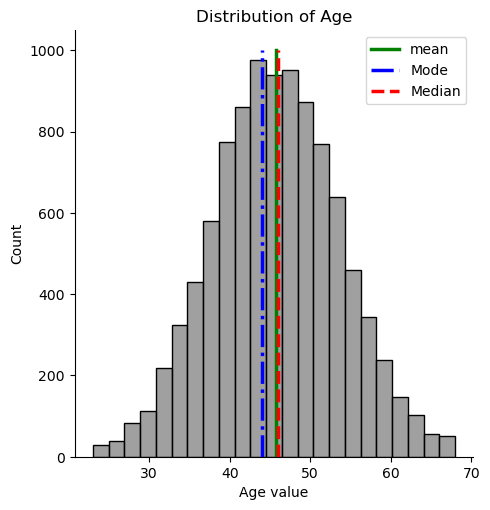

In [10]:
plt.figure(figsize=(3, 3))

y = np.linspace(0, 1000, 1000)
sns.displot(df_train["age"], bins=23, color="grey", kde=False)
plt.plot([age_mean] * 1000, y, color="green", linewidth=2.5, label="mean")
plt.plot([age_mode] * 1000, y, color="blue", linewidth=2.5, label="Mode", linestyle="-.")
plt.plot([age_median] * 1000, y, color="red", linewidth=2.5, label="Median", linestyle="dashed")

plt.title("Distribution of Age")
plt.ylabel("Count")
plt.xlabel("Age value")
plt.legend(loc="upper right")

plt.show()

### Lesson price

In [11]:
lesson_price_mean, lesson_price_median, lesson_price_mode = measures_of_the_central_trend(df_train["lesson_price"])
print(f"Measures of the central trend for lesson_price:\nMean - {lesson_price_mean}\nMode - {lesson_price_mode}\nMedian - {lesson_price_median}")

Measures of the central trend for lesson_price:
Mean - 1702.44
Mode - 1450.0
Median - 1550.0


<Figure size 300x300 with 0 Axes>

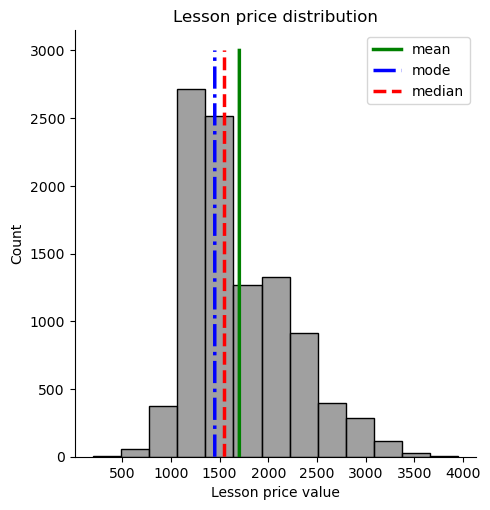

In [12]:
plt.figure(figsize=(3, 3))

y = np.linspace(0, 3000, 3000)
sns.displot(df_train["lesson_price"], bins=13, color="grey", kde=False)
plt.plot([lesson_price_mean] * 3000, y, color="green", linewidth=2.5, label="mean")
plt.plot([lesson_price_mode] * 3000, y, color="blue", linewidth=2.5, linestyle="-.", label="mode")
plt.plot([lesson_price_median] * 3000, y, color="red", linewidth=2.5, linestyle="dashed", label="median")

plt.title("Lesson price distribution")
plt.ylabel("Count")
plt.xlabel("Lesson price value")
plt.legend(loc="upper right")

plt.show()

### Mean exam points

In [7]:
mean_exam_points_mean, mean_exam_points_median, mean_exam_points_mode = measures_of_the_central_trend(df_train["mean_exam_points"])
print(
    f"Measures of the central trend for mean_exam_points_:\nMean - {mean_exam_points_mean}\nMode - {mean_exam_points_mode}\nMedian - "\
    f"{mean_exam_points_median}"
)

Measures of the central trend for mean_exam_points_:
Mean - 64.4352
Mode - 62.0
Median - 63.0


<Figure size 300x300 with 0 Axes>

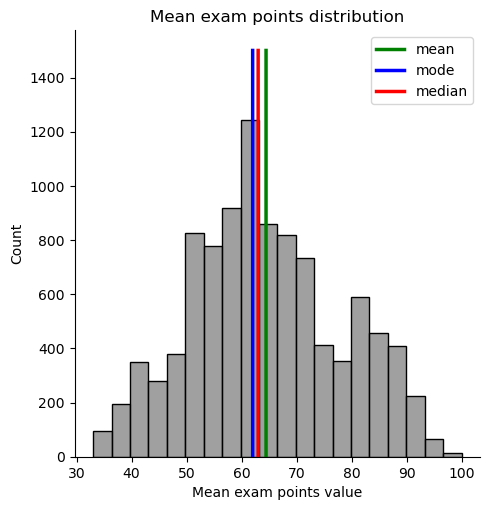

In [9]:
plt.figure(figsize=(3, 3))

y = np.linspace(0, 1500, 1500)
sns.displot(df_train["mean_exam_points"], bins=20, color="grey", kde=False)
plt.plot([mean_exam_points_mean] * 1500, y, color="green", linewidth=2.5, label="mean")
plt.plot([mean_exam_points_mode] * 1500, y, color="blue", linewidth=2.5, label="mode")
plt.plot([mean_exam_points_median] * 1500, y, color="red", linewidth=2.5, label="median")

plt.title("Mean exam points distribution")
plt.ylabel("Count")
plt.xlabel("Mean exam points value")
plt.legend(loc="upper right")

plt.show()

According to the histogram, Age and Mean exam points distributions tend to be normal, at the same time Lesson prise distribution has Asymmetrically type of distribution. Max point of exam do not exceed 100 and min point value is above zero.

The Age of Majority's tutors placed between 40 and 50. Mode and mean values are almost identical 44.0, 45.8 respectively, therefore this distribution realy tends to be normal.

Measures of the central trend for Mean exam points are quite close to each other (62, 63, 64.4)

The most popular Lesson prices located between 1100 and 1500. The biggest price is 4000, the smallest is 200. So now, this data is apears to be clear

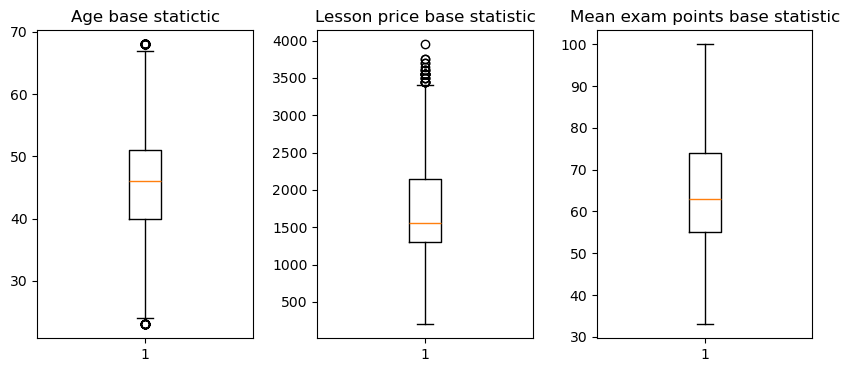

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 4))

ax1, ax2, ax3 = axes.flatten()

ax1.boxplot(df_train["age"])
ax1.set_title("Age base statictic")

ax2.boxplot(df_train["lesson_price"])
ax2.set_title("Lesson price base statistic")

ax3.boxplot(df_train["mean_exam_points"])
ax3.set_title("Mean exam points base statistic")

plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

According to these base statistic figures Age and Lesson price have outliers. Calculate quantlies and IQR.

In [148]:
# Function for calculating quartiles
def culculate_quantiles(data: pd.Series):
    q1 = data.quantile(.25)
    q3 = data.quantile(.75)
    iqr = q3 - q1
    return q1, q3, iqr

In [17]:
age_q1, age_q3, age_iqr = culculate_quantiles(df_train["age"])
print(f"Age Q1 - {age_q1}, Q3 - {age_q3}, IQR - {age_iqr}")
outliers_age = df_train.loc[(df_train["age"] > age_q3 + 1.5 * age_iqr) | (df_train["age"] < age_q1 - age_iqr * 1.5), :]

Age Q1 - 40.0, Q3 - 51.0, IQR - 11.0


In [18]:
outliers_age.sort_values(by=["age", "choose"], ascending=True)

,age,years_of_experience,lesson_price,qualification,physics,chemistry,biology,english,geography,history,mean_exam_points,choose
89,23.0,1.0,2150.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,83.0,0
144,23.0,0.0,1400.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,57.0,0
251,23.0,1.0,1100.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,65.0,0
1754,23.0,0.0,2700.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,82.0,0
2035,23.0,1.0,1500.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,51.0,0
2375,23.0,1.0,2600.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,86.0,0
2460,23.0,5.0,2300.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,83.0,0
2652,23.0,1.0,1450.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,0
2718,23.0,2.0,2350.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,65.0,0
4456,23.0,2.0,2800.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,87.0,0


In [19]:
lesson_price_q1, lesson_price_q3, lesson_price_iqr = culculate_quantiles(df_train["lesson_price"])
print(f"Lesson price Q1 - {lesson_price_q1}, Q3 - {lesson_price_q3}, IQR - {lesson_price_iqr}")
outliers_lesson_price = df_train.loc[
    (df_train["lesson_price"] > lesson_price_q3 + 1.5 * lesson_price_iqr) | (df_train["lesson_price"] < lesson_price_q1 - lesson_price_iqr * 1.5), :
    ]

Lesson price Q1 - 1300.0, Q3 - 2150.0, IQR - 850.0


In [20]:
outliers_lesson_price.sort_values(by=["lesson_price", "choose"])

,age,years_of_experience,lesson_price,qualification,physics,chemistry,biology,english,geography,history,mean_exam_points,choose
157,59.0,7.0,3450.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,95.0,0
1863,55.0,6.0,3450.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,85.0,0
1934,56.0,6.0,3450.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,87.0,0
2522,50.0,5.0,3450.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,93.0,0
9015,49.0,5.0,3450.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,88.0,0
865,58.0,6.0,3500.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,87.0,0
1003,52.0,6.0,3500.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,91.0,0
3327,62.0,7.0,3500.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,82.0,0
132,62.0,7.0,3550.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,83.0,0
1087,51.0,5.0,3550.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,85.0,0


No one tutors were chosen who have price above Q3 + IQR and less Q1 - IQR. As regards age, there is only one tutor chosen, who was younger than Q1 - IQR and 4 tutors older Q3 + IQR

**Maybe I should create new feature "Lesson price" with outliers pointing model, that too big and too small price is not right way to choose tutor.**

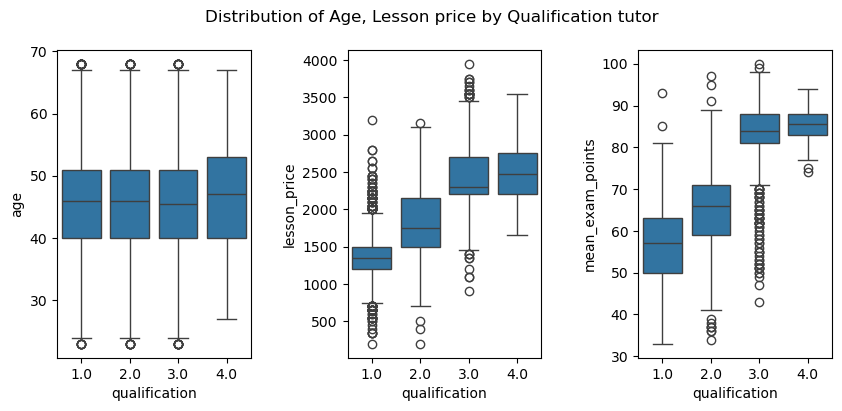

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 4))

fig.suptitle("Distribution of Age, Lesson price by Qualification tutor")

sns.boxplot(data=df_train, x="qualification", y="age", ax=axes[0])
sns.boxplot(data=df_train, x="qualification", y="lesson_price", ax=axes[1])

sns.boxplot(data=df_train, x="qualification", y="mean_exam_points", ax=axes[2])

plt.subplots_adjust(wspace=0.5, hspace=0.3)
plt.show()

The average age is higher for tutors of 4 qualification. The same trend displayed for lesson price and mean exam points. Lesson price, mean exam points tutors of 4 qualification much more than the same rates of tutors smaller qualification. At the same time there are a lot of students have points less than 70 who had been tought by tutor of 3 qualification

<Figure size 200x200 with 0 Axes>

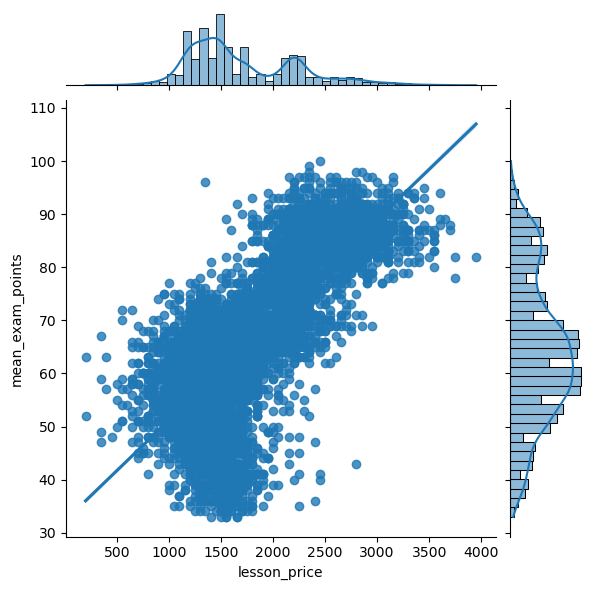

In [22]:
plt.figure(figsize=(2, 2))

sns.jointplot(data=df_train, x="lesson_price", y="mean_exam_points", kind="reg")

plt.show()

As the prices rice so do mean exam points.

## Categorical variables

In [23]:
chosen = df_train.loc[df_train["choose"] == 1, "choose"].count()
not_chosen = df_train.loc[df_train["choose"] == 0, "choose"].count()
print(f"Number of chosen - {chosen}, number of not chosen - {not_chosen}")

Number of chosen - 1109, number of not chosen - 8891


In [72]:
category = ["physics", "chemistry", "biology", "english", "geography", "history"]

In [25]:
df_train_cat = df_train[category].apply(lambda x: x.sum(), axis=0)

In [26]:
df_train_cat["no_subjects"] = df_train[category].apply(lambda x: sum([1 if i == 0 else 0 for i in x]) == 6, axis=1).sum()

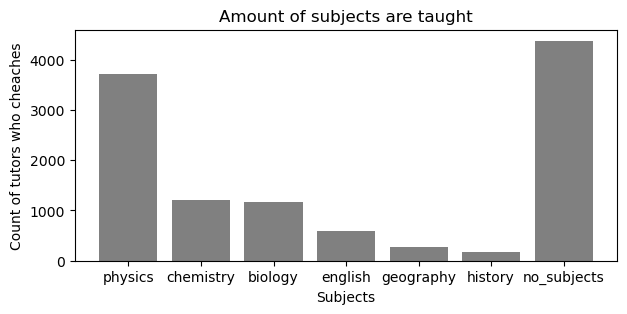

In [27]:
plt.figure(figsize=(7, 3))

plt.bar(df_train_cat.index, df_train_cat, color="grey")
plt.title("Amount of subjects are taught")
plt.xlabel("Subjects")
plt.ylabel("Count of tutors who cheaches")

plt.show()

The most popular subject is physics - above 3500, unpopular is history - less 500. Chemistry and biology are located almost at the same level - 1200. But the biggest number tutors is tutors who do not have subjects (more than 4300)

In [28]:
choose_by_qualification = df_train.groupby(by="qualification").agg({"choose": "sum"})
choose_by_qualification

,choose
qualification,
1.0,504
2.0,317
3.0,272
4.0,16


Majority of students chose tutor of 1 qualification - 504 tuturs. Tutors with forth qualification ternd out to be the most unpopular

In [29]:
chosen_tutor_by_physics_and_chemistry = pd.pivot_table(
    data=df_train, columns=["physics"], values="choose", aggfunc="sum"
)
chosen_tutor_by_physics_and_chemistry

physics,0.0,1.0
choose,402,707


Tutors teach physics (707) (and were chosen) is the biggest portion of all chosen (1109).

In [30]:
exp = pd.pivot_table(
    data=df_train, columns=["biology", "history"], values="choose", aggfunc="sum"
)
exp

biology  0.0      1.0    
history  0.0 1.0  0.0 1.0
choose   895  12  196   6

In [31]:
exp = pd.pivot_table(
    data=df_train, index="qualification", columns=["biology", "history","geography"], values="choose", aggfunc="sum"
)
exp

biology          0.0                   1.0          
history          0.0        1.0        0.0       1.0
geography        0.0   1.0  0.0  1.0   0.0  1.0  0.0
qualification                                       
1.0            389.0  14.0  6.0  0.0  90.0  3.0  2.0
2.0            253.0   7.0  4.0  NaN  49.0  2.0  2.0
3.0            210.0   7.0  2.0  0.0  50.0  1.0  2.0
4.0             15.0   0.0  0.0  NaN   1.0  0.0  NaN

Between all subjects intresting observations were found:
- Student preferd tutors who do not teach biology, history and geography (867)
- Tutors with physics were preferable (707)

But should take into account that this information does not include information about other feature

**Let's try to figure out what can be deeper in this combination: biology, history and geography**

In [145]:
no_biology_no_history_no_geography = df_train.loc[
    (df_train["biology"] == 0) & 
    (df_train["history"] == 0) & 
    (df_train["choose"] == 1) & 
    (df_train["geography"] == 0), :
    ]
# no_biology_no_history.loc[(no_biology_no_history["lesson_price"] < 2200) & (no_biology_no_history["qualification"] == 1)]

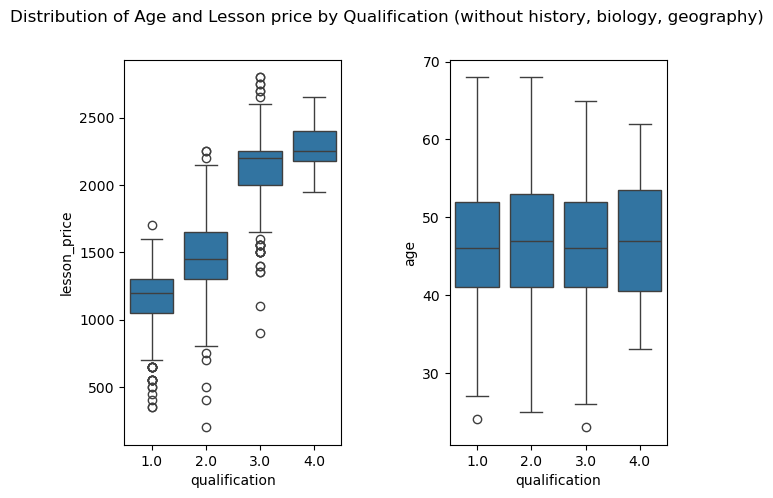

In [146]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 5))

fig.suptitle("Distribution of Age and Lesson price by Qualification (without history, biology, geography)")

sns.boxplot(ax=axes[0], data=no_biology_no_history_no_geography, x="qualification", y="lesson_price")
sns.boxplot(ax=axes[1], data=no_biology_no_history_no_geography, x="qualification", y="age")

plt.subplots_adjust(wspace=0.5, hspace=0.3)
plt.show()

As we can see, the bigger qualification the higher lesson price. There is no big difference in mean age of tutors different qualification, but variance is getting less closer to 4 qualification.

In [149]:
n_his_n_bio_n_geo_q1, n_his_n_bio_n_geo_q3, n_his_n_bio_n_geo_iqr = culculate_quantiles(no_biology_no_history_no_geography["lesson_price"])
print(
    f"Quartiles for Lesson price (biology, history, geography) Q1 - {n_his_n_bio_n_geo_q1}, Q3 - {n_his_n_bio_n_geo_q3}, IQR {n_his_n_bio_n_geo_iqr}"
)

Quartiles for Lesson price (biology, history, geography) Q1 - 1200.0, Q3 - 1750.0, IQR 550.0


In [150]:
hbg_outliers_down = n_his_n_bio_n_geo_q1 - 1.5 * n_his_n_bio_n_geo_iqr
hbg_outliers_up = n_his_n_bio_n_geo_q3 + 1.5 * n_his_n_bio_n_geo_iqr
hbg_outliers_down, hbg_outliers_up

(np.float64(375.0), np.float64(2575.0))

In [151]:
amount_bhg_without_outliers = no_biology_no_history_no_geography.loc[
    (no_biology_no_history_no_geography["lesson_price"] > hbg_outliers_down) & (no_biology_no_history_no_geography["lesson_price"] < hbg_outliers_up)
    ].shape[0]
print(f"Amount of tutors (no history, biology, geography) with too big and too small lesson price - {no_biology_no_history_no_geography.shape[0]}." \
      f" Without outliers in price {amount_bhg_without_outliers}"
     )

Amount of tutors (no history, biology, geography) with too big and too small lesson price - 867. Without outliers in price 855


Lesson price outliers reducing showed negative outcome. Amount of tutors with outliers bigger than without.

**Trying to make combination with biology, history, geography and physics**

In [37]:
pd.pivot_table(data=df_train, index="choose", values="physics", aggfunc="sum", columns=["biology", "history", "geography"])

biology       0.0                     1.0          
history       0.0         1.0         0.0       1.0
geography     0.0   1.0   0.0  1.0    0.0  1.0  0.0
choose                                             
0          2566.0  75.0  51.0  0.0  303.0  2.0  2.0
1           568.0  12.0  11.0  NaN  112.0  1.0  3.0

In [38]:
pd.pivot_table(
    data=df_train, columns=["biology", "history", "physics"], values="choose", aggfunc="sum"
)

biology  0.0              1.0             
history  0.0      1.0     0.0      1.0    
physics  0.0  1.0 0.0 1.0 0.0  1.0 0.0 1.0
choose   315  580   1  11  83  113   3   3

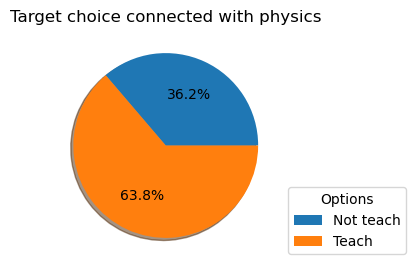

In [39]:
plt.figure(figsize=(3, 3))

plt.pie(
    x=df_train.groupby(by=["physics"]).agg({"choose": "sum"})["choose"],
    autopct='%1.1f%%',
    shadow=True
)

plt.title("Target choice connected with physics")
plt.legend(
title="Options",
loc="lower left",
bbox_to_anchor=(1, 0, 0.5, 1),
labels=["Not teach", "Teach"]
)


plt.show()

The total number of tutors who teach physics is 3706. The amount of tuturs who have been chosen is 707. Of these 568 do not teach history, biology, and geography. This number is almost 81% of chosen tutors connected with physics.

- From the one hand almost all chosen physics tutors are represented by combination: no history, biology, and geography but physics.
- But on the other hand the same combination gives outcome of 2566 tutors who were not chosen

In order to predict the right tutors connected with physics we can consider this as a new feature

In [76]:
category

['physics', 'chemistry', 'biology', 'english', 'geography', 'history']

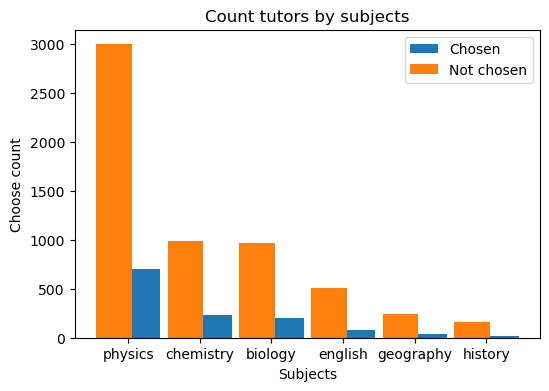

In [144]:
plt.figure(figsize=(6, 4))

xpos = np.arange(len(category))

plt.bar(xpos + 0.2, df_train.loc[df_train["choose"] == 1, category].sum().values, label="Chosen", width=0.5)
plt.bar(xpos - 0.2, df_train.loc[df_train["choose"] == 0, category].sum().values, label="Not chosen", width=0.5)

plt.xticks(ticks=xpos, labels=category)
plt.xlabel("Subjects")
plt.ylabel("Choose count")
plt.title("Count tutors by subjects")
plt.legend(loc="upper right")

plt.show()

A little percent of chosen tutors who teach their subject exists in all category. This value is quite small, especially in history, geography and english.

In [152]:
# History
pd.pivot_table(data=df_train, values="choose", aggfunc="sum", columns="history")

history,0.0,1.0
choose,1091,18


The total number of tutors with history - 180. Of these 18 have been chosen -> therefore tutor with history has the big chances not to be chosen

In [43]:
no_subjects_idx = df_train[category].apply(lambda x: sum([1 if i == 0 else 0 for i in x]) == 6, axis=1)
not_sub = df_train[no_subjects_idx]
not_sub_chosen = not_sub.loc[not_sub["choose"] == 1].shape[0]
print(
    f"The total number tutors who do not teach any subjects - {not_sub.shape[0]}. " \
    f"Of these {not_sub_chosen} were chosen and {not_sub.shape[0] - not_sub_chosen} were not chosen"
)

The total number tutors who do not teach any subjects - 4381. Of these 207 were chosen and 4174 were not chosen


There is big possibility for tutor who does not teach any subjucts not to be chosen

<Figure size 300x300 with 0 Axes>

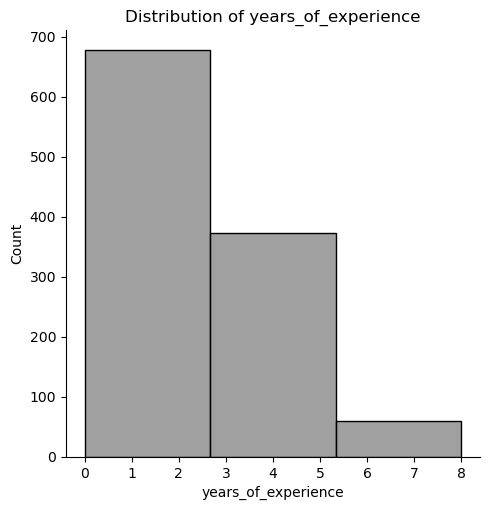

In [120]:
plt.figure(figsize=(3, 3))

sns.displot(df_train.loc[df_train["choose"] == 1, "years_of_experience"], bins=3, color="grey", kde=False, )

plt.title("Distribution of years_of_experience")
plt.ylabel("Count")
plt.xlabel("years_of_experience")

plt.show()

<Figure size 300x300 with 0 Axes>

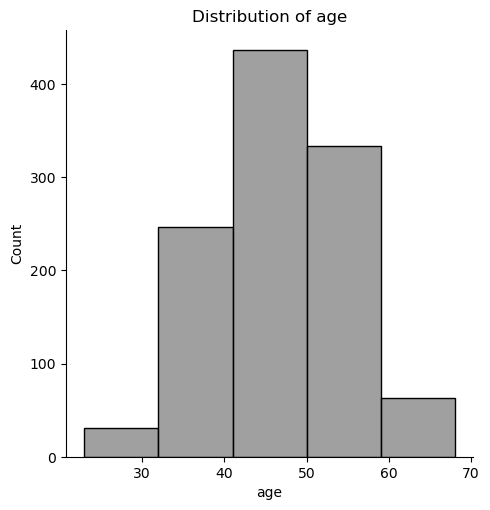

In [6]:
plt.figure(figsize=(3, 3))

sns.displot(df_train.loc[df_train["choose"] == 1, "age"], bins=5, color="grey", kde=False, )

plt.title("Distribution of age")
plt.ylabel("Count")
plt.xlabel("age")

plt.show()

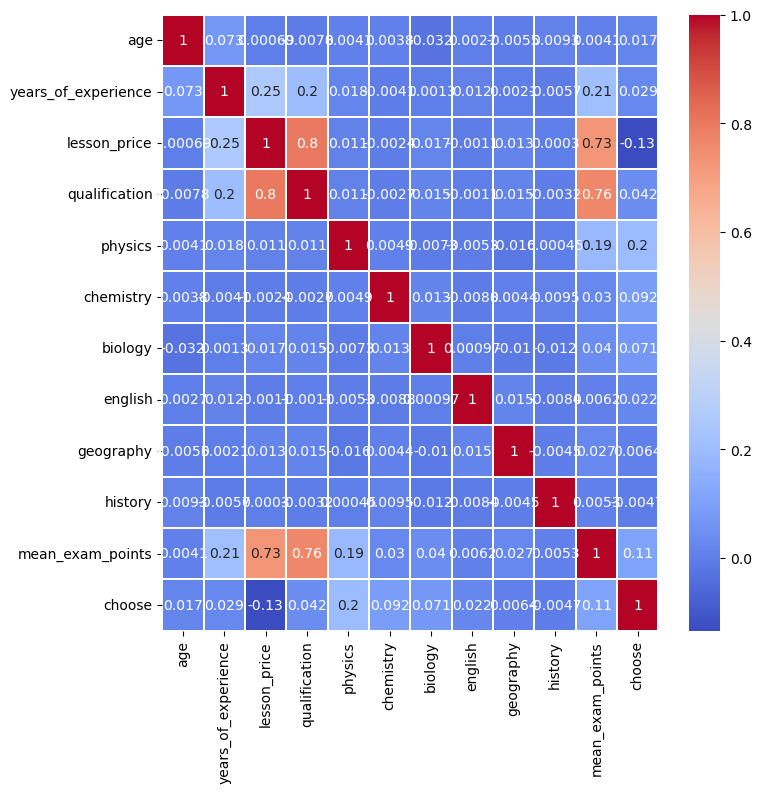

In [339]:
plt.figure(figsize=(8, 8))

matrix_corr = df_train.corr()

sns.heatmap(data=matrix_corr, annot=True, cmap="coolwarm", linewidths=0.3)

plt.show()

There is a big correlations between lesson price and qualification, lesson price and mean exam points, qualification and mean exam points.

But in this stage I can leave it in the data.

## Baseline model

### Logistic Regression

In [133]:
class MyLogisticRegression:

    def __init__(self, iterations, eta, threshold=0.5, random_state=None, reg=1e-8):
        self.iterations = iterations
        self.eta = eta
        self.threshold = threshold
        self.reg = reg
        self.rng_model = np.random.RandomState(random_state)
        self.min_weight_dist = 1e-4
        self.errors = []
        self.weights = None
        self.final_error = 0
        self.best_val_loss = np.inf
        self.best_weights = None
        self.patience = 10
        self.f1 = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def logloss(self, y, y_pred):
        eps = 1e-8
        y_pred = np.clip(y_pred, eps, 1 - eps)
        loss = - np.mean(y * np.log(y_pred) + (1.0 - y) * np.log(1.0 - y_pred))

        return loss

    def find_best_threshold(self, y, y_prob):
        best_threshold = 0.5
        best_f1 = 0
    
        thresholds = np.linspace(0.05, 0.95, 91)

        for thr in thresholds:
            y_pred = (y_prob > thr).astype(int)
        
            tp = np.sum((y_pred == 1) & (y == 1))
            fp = np.sum((y_pred == 1) & (y == 0))
            fn = np.sum((y_pred == 0) & (y == 1))

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0

            if (precision + recall) > 0:
                f1 = 2 * (precision * recall) / (precision + recall)
            else:
                f1 = 0
                
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = thr

        self.threshold = best_threshold
        self.f1 = best_f1
        return self.threshold

    def eval_model(self, X, y, X_valid, y_valid):
        W = self.rng_model.randn(X.shape[1])
        n = X.shape[0]
        patience_counter = 0

        for i in range(self.iterations):
            z = np.dot(X, W)
            y_pred = self.sigmoid(z)

            err = self.logloss(y, y_pred)
            self.errors.append(err)

            if i % 100 == 0:
                val_loss = self.logloss(y_valid, self.sigmoid(X_valid @ W))
                if val_loss < self.best_val_loss:
                    self.best_val_loss = val_loss
                    self.best_weights = W.copy()
                    patience_counter = 0
                else:
                    patience_counter += 1
                if patience_counter > self.patience:
                    print(f"Early stopping on iteration {i}")
                    break

            dQ = 1 / n * X.T @ (y_pred - y)
            dReg = 2 * self.reg * W if self.reg > 0 else 0
            next_w = W - self.eta * (dQ + dReg)

            if np.linalg.norm(W - next_w) < self.min_weight_dist:
                W = next_w
                break
            
            W = next_w

        if self.best_weights is not None:
            self.weights = self.best_weights
        else:
            self.weights = W
            
        self.final_error = err

    def calc_prediction(self, X):
        if self.weights is None:
            raise ValueError("You did not fit model")
        probabilities = self.sigmoid(np.dot(X, self.weights))
        predictions = np.where(probabilities > self.threshold, 1, 0)
        print("Min possibility:", np.min(probabilities))
        print("Max possibility:", np.max(probabilities))
        print("Mean possibility:", np.mean(probabilities))
        print("Current weights:", self.weights)
        return predictions, probabilities

### Write Standard Scaler

In [129]:
class MyStandardScaler:

    def __init__(self, columns_to_scale):
        self.fitted_values = {}
        self.columns_to_scale = columns_to_scale

    def fit(self, df):
        for col in self.columns_to_scale:
            x_mean = np.mean(df[col])
            x_std = np.std(df[col])
            self.fitted_values[col] = {"mean": x_mean, "std": x_std}

        return self
        
    def transform(self, df):
        if not self.fitted_values:
            raise ValueError("You did not fit scaler. First, use method fit")
        scaled_df = df.copy()#.astype(np.float64)
        for col in self.columns_to_scale:
            mean = self.fitted_values[col]["mean"]
            std = self.fitted_values[col]["std"]

            scaled_df[col] = (scaled_df[col] - mean) / std# + 1e-8)
        return scaled_df

### Evaluater class for calculating metrixs and charts

In [7]:
class EvaluateModel:

    def __init__(self, y_pred, y_pred_proba, y):
        self.y_predictions = y_pred
        self.y_predictions_probability = y_pred_proba
        self.y_target = y
        self.confusion_matrix = None
        self.precision = None
        self.recall = None
        self.accuracy = None
        self.tpr = None
        self.fpr = None
        self.auc_roc_score = None
        self.auc_pr_score = None

    def evaluation(self, show_charts=False):
        self.calc_confusion_matrix()
        self.calc_metrix_from_confusion_matrix()

        tpr_list, fpr_list = self.calc_roc_auc()
        precision_list, recall_list = self.calc_pr_roc_auc()
        if show_charts:

            fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5))
            ax1, ax2 = axes.flatten()
    
            fig.suptitle("ROC-AUC and PR-AUC curves")
    
            ax1.plot(fpr_list, tpr_list)
            ax1.set_title("ROC curve")
            ax1.set_xlabel('FPR')
            ax1.set_ylabel('TPR')
            ax1.grid()
            ax1.legend(' ', title=f'AUC-ROC={self.auc_roc_score:.3f}', loc='lower right')
    
            ax2.plot(recall_list, precision_list)
            ax2.set_title("PR curve")
            ax2.set_xlabel('Recall')
            ax2.set_ylabel('Precision')
            ax2.grid()
            ax2.legend('', title=f'AUC-PR={self.auc_pr_score:.3f}', loc='lower right')
            
            plt.show()

    def calc_confusion_matrix(self):
        eps = 1e-8
        
        true_negative = np.sum((self.y_predictions == 0) & (self.y_target == 0))
        false_positive = np.sum((self.y_predictions == 1) & (self.y_target == 0))
        false_negative = np.sum((self.y_predictions == 0) & (self.y_target == 1))
        true_positive = np.sum((self.y_predictions == 1) & (self.y_target == 1))
    
        self.confusion_matrix = np.array([
            [true_positive, false_positive],
            [false_negative, true_negative]
        ])
    
    def calc_metrix_from_confusion_matrix(self):
        tp, fp, fn, tn = self.confusion_matrix[0][0], self.confusion_matrix[0][1], self.confusion_matrix[1][0], self.confusion_matrix[1][1]
    
        self.precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        self.recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        self.accuracy = np.sum(self.y_predictions == self.y_target) / self.y_target.shape[0]
    
        self.tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        self.fpr = fp / (fp + tn) if (fp + tn) > 0 else 0 

    def calc_roc_auc(self):
    
        df = pd.DataFrame({
            "y_true": self.y_target, 
            "possibility": self.y_predictions_probability
        })
        df = df.sort_values(by="possibility", ascending=False)
        
        P = (df["y_true"] == 1).sum()
        N = (df["y_true"] == 0).sum()
    
        tpr_list = [0.0]
        fpr_list = [0.0]
    
        TP = 0
        FP = 0
    
        for _, row in df.iterrows():
            if row["y_true"] == 1:
                TP += 1
            else:
                FP += 1
    
            tpr_list.append(TP / P)
            fpr_list.append(FP / N)
                
        self.auc_roc_score = np.trapezoid(tpr_list, fpr_list)
    
        return tpr_list, fpr_list

    def calc_pr_roc_auc(self):
        df = pd.DataFrame({
            "y_true": self.y_target, 
            "possibility": self.y_predictions_probability
        })
        df = df.sort_values(by="possibility", ascending=False)
        
        P = (df["y_true"] == 1).sum()
        N = (df["y_true"] == 0).sum()
    
        precision_list = [1.0]
        recall_list = [0.0]
    
        TP = 0
        FP = 0
    
        for _, row in df.iterrows():
            if row["y_true"] == 1:
                TP += 1
            else:
                FP += 1
    
            precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
            recall = TP / (P)
            precision_list.append(precision)
            recall_list.append(recall)
    
        final_precision = P / (P + N) if (P + N) > 0 else 0.0
        precision_list.append(final_precision)
        recall_list.append(1.0)
        
        self.auc_pr_score = np.trapezoid(precision_list, recall_list)
            
        return precision_list, recall_list

    def show_errors(self, errors):
        plt.figure(figsize=(3, 3))

        plt.plot(range(len(errors)), errors)
        
        plt.title('Log loss')
        plt.xlabel('iterations')
        plt.ylabel('loss')
        plt.grid()
        
        plt.show()

### Pipline class for fitting

In [8]:
class Processing:

    def __init__(
        self, data, modify_cat=None, columns_to_drop=None, columns_to_create=None, columns_to_scale=None, method=None, n_iter=1000, lr=0.05, 
        strategy="auto", reg=1e-8, simple_test=42
    ):
        self.X = data.copy()
        self.modify_cat = modify_cat
        self.columns_to_scale = columns_to_scale
        self.columns_to_drop=columns_to_drop
        self.columns_to_create=columns_to_create
        self.y = None
        self.column_names = None
        self.method = method
        self.n_iter = n_iter
        self.lr = lr
        self.strategy = strategy
        self.reg = reg
        self.simple_test = simple_test

    def start_process(self):
        
        X_train, X_valid, X_test, y_train, y_valid, y_test = self.split_and_get()
        
        if self.modify_cat:
            X_train, X_valid = self.modify_categories([X_train, X_valid])
        
        if self.columns_to_create:
            X_train, X_valid = self.create_columns([X_train, X_valid])

        if self.columns_to_drop:
            X_train, X_valid = self.drop_features([X_train, X_valid])
            self.check_drop_list()
        self.column_names = X_train.columns

        if self.method:
            X_train, y_train = self.make_balance_in_classes(X_train, y_train, self.method)
        
        scaler = MyStandardScaler(columns_to_scale=self.columns_to_scale)
        scaler.fit(X_train)

        X_train_scaled = scaler.transform(X_train)
        X_valid_scaled = scaler.transform(X_valid)

        X_train_scaled, X_valid_scaled = self.add_fiction_feature([X_train_scaled, X_valid_scaled])
        
        model = MyLogisticRegression(iterations=self.n_iter, eta=self.lr, reg=self.reg, random_state=self.simple_test)
        model.eval_model(X=X_train_scaled, y=y_train, X_valid=X_valid_scaled, y_valid=y_valid)
        train_predictions, train_proba = model.calc_prediction(X=X_train_scaled)
        valid_predictions, valid_proba = model.calc_prediction(X=X_valid_scaled)

        return valid_predictions, valid_proba, train_predictions, train_proba, model, y_train, y_valid

    def add_fiction_feature(self, df_list):
        
        ready_df = []
        
        for df in df_list:
            intercept = np.ones((df.shape[0], 1))
            ready_df.append(np.hstack([intercept, df]))

        self.column_names = ["W0"] + list(self.column_names)
        
        return ready_df

    def drop_features(self, df_list):

        modifyed_df = []
        
        for df in df_list:
            new_df = df.drop(self.columns_to_drop, axis=1)
            modifyed_df.append(new_df)
        return modifyed_df

    def check_drop_list(self):

        self.columns_to_scale = [col for col in self.columns_to_scale if col not in self.columns_to_drop]

    def modify_categories(self, df_list):
        
        modifyed_df = []
        
        for df in df_list:
            df = pd.concat([df, pd.get_dummies(df[self.modify_cat], prefix="q", dtype=int)], axis=1)
            df.drop([self.modify_cat], axis=1, inplace=True)
            modifyed_df.append(df)
        return modifyed_df

    def create_columns(self, df_list):
        
        modifyed_df = []
        train_statistic_data = {}
        
        for col in self.columns_to_create:
            if self.columns_to_create[col][2] not in ["binning", "bool"]:
                self.columns_to_scale.append(col)

        for df in df_list:
            df_copy = df.copy()
            for col in self.columns_to_create:
                spec = self.columns_to_create[col]
                operation = spec[2]
                
                if operation == "divide":
                    if "years_of_experience" in spec:
                        df_copy[col] = df_copy[spec[0]] / (df_copy[spec[1]] + 1)
                    else:
                        df_copy[col] = df_copy[spec[0]] / df_copy[spec[1]]
                elif operation == "multiply":
                    if "years_of_experience" in spec:
                        df_copy[col] = df_copy[spec[0]] * (df_copy[spec[1]] + 1)
                    else:
                        df_copy[col] = df_copy[spec[0]] * df_copy[spec[1]]
                elif operation == "combo_multiply":
                    df_copy[col] = df_copy[spec[0][0]] * df_copy[spec[0][1]] / df_copy[spec[1]]
                elif operation == "binning":
                    # bins = [0, 3, 6, float('inf')]  # 0-2, 3-5, 6+ GOOD ONE FOR experience
                    # bins = [0, 31, 41, 51, 61, float('inf')] # 0-30, 31-40, 40-50, 51-60, 61+ GOOD ONE FOR age
                    # labels = [1, 2, 3, 4, 5]
                    bins = spec[1]["bins"]
                    labels = spec[1]["labels"]
                    binned = pd.cut(
                        df_copy[spec[0]],
                        bins=bins,
                        labels=labels,
                        right=False
                    )
                    dummies = pd.get_dummies(binned, prefix=col, dtype=int)
                    df_copy = pd.concat([df_copy, dummies], axis=1)
                    
                elif operation == "mean_by_group":
                    df_copy[col] = df_copy.groupby(by=spec[0])[spec[1]].transform(lambda x: x - x.mean())
                elif operation == "count":
                    df_copy[col] = df_copy[spec[1]].sum(axis=1)
                elif operation == "minus":
                    df_copy[col] = df_copy[spec[0]] - df_copy[spec[1]]
                elif operation == "bool":
                    df_copy[col] = 0
                    if len(train_statistic_data) == 0:
                        statisics = df_copy.groupby(by="qualification").agg(
                            median_points = (spec[0], "median"),
                            median_price = (spec[1], "median")
                        )
                        for qual in statisics.index:
                            train_statistic_data[qual] = {
                                "median_points": statisics.loc[qual].median_points, "median_price": statisics.loc[qual].median_price
                            }
                    for qual in train_statistic_data:
                        df_copy.loc[
                            (df_copy["qualification"] == int(qual)) & 
                            (df_copy[spec[0]] >= train_statistic_data[qual]["median_points"]) &
                            (df_copy[spec[1]] < train_statistic_data[qual]["median_price"]),
                            col
                            ] = 1

            modifyed_df.append(df_copy)
            
        return modifyed_df

    def make_balance_in_classes(self, X_train, y_train, method=None):
        if method == "smote":
            sampler = over_sampling.SMOTE(sampling_strategy=self.strategy, random_state=self.simple_test)#42)
        elif method == "oversample":
            sampler = over_sampling.RandomOverSampler(sampling_strategy='auto', random_state=self.simple_test)#42)
        elif method == "undersample":
            sampler = under_sampling.RandomUnderSampler(sampling_strategy='auto', random_state=self.simple_test)#42)
        elif method == "adasyn":
            sampler = over_sampling.ADASYN(sampling_strategy=self.strategy, n_neighbors=5, random_state=self.simple_test)#42)
        else:
            return X_train, y_train

        X_balanced, y_balanced = sampler.fit_resample(X_train, y_train)
        X_balanced = pd.DataFrame(X_balanced, columns=list(self.column_names))
        return X_balanced, y_balanced

    def split_and_get(self):
        self.y = self.X["choose"]
        X_train, X_temp, y_train, y_temp = self.split_test_train(X=self.X, y=self.y, proportion=0.6, random_state=self.simple_test)#42)
        X_valid, X_test, y_valid, y_test = self.split_test_train(X=X_temp, y=y_temp, proportion=0.5, random_state=self.simple_test)#42)
        return X_train, X_valid, X_test, y_train, y_valid, y_test
        
    def split_test_train(self, X, y, proportion, random_state=None):
        y.reset_index(drop=True, inplace=True)
        rng_split = np.random.RandomState(random_state)
        
        idx_1 = np.where(y == 1)[0]
        idx_0 = np.where(y == 0)[0]
        
        rng_split.shuffle(idx_1)
        rng_split.shuffle(idx_0)
        
        portion_1 = int(np.round(idx_1.shape[0] * proportion))
        portion_0 = int(np.round(idx_0.shape[0] * proportion))
        
        train_idx = np.concat([idx_1[: portion_1], idx_0[: portion_0]])
        test_idx = np.concat([idx_1[portion_1: ], idx_0[portion_0: ]])
        
        rng_split.shuffle(train_idx)
        rng_split.shuffle(test_idx)
        
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        
        return X_train, X_test, y_train, y_test

### Pipeline class for processing

In [141]:
class Pipeline:

    def __init__(self):
        self.scaler = None
        self.model = None
        self.column_names =  None
        self.columns_to_scale = None
        self.columns_to_create = None
        self.columns_to_drop = None

    def fit_model(
        self, data, columns_to_drop=None, columns_to_create=None, columns_to_scale=None, method=None, n_iter=1000, lr=0.05, 
        strategy="auto", reg=1e-8, random_state=None
    ):
        X, y = data.copy()[data.columns[:-1]], data.copy()["choose"]
        self.columns_to_scale = columns_to_scale
        self.columns_to_drop = columns_to_drop
        self.columns_to_create = columns_to_create

        X_train, X_valid, y_train, y_valid = self.split_test_train(X=X, y=y, proportion=0.8, random_state=random_state)

        if columns_to_create:
            X_train, X_valid = self.create_columns([X_train, X_valid], columns_to_create)

        if columns_to_drop:
            X_train, X_valid = self.drop_features([X_train, X_valid], columns_to_drop)
            self.check_drop_list(columns_to_drop=columns_to_drop)
        self.column_names = X_train.columns

        if method:
            X_train, y_train = self.make_balance_in_classes(X_train, y_train, strategy=strategy, method=method, random_state=random_state)

        self.scaler = MyStandardScaler(columns_to_scale=self.columns_to_scale)
        self.scaler.fit(X_train)

        X_train_scaled = self.scaler.transform(X_train)
        X_valid_scaled = self.scaler.transform(X_valid)

        X_train_scaled, X_valid_scaled = self.add_fiction_feature([X_train_scaled, X_valid_scaled])
        
        self.model = MyLogisticRegression(iterations=n_iter, eta=lr, reg=reg, random_state=random_state)
        self.model.eval_model(X=X_train_scaled, y=y_train, X_valid=X_valid_scaled, y_valid=y_valid)
        
        train_predictions, train_proba = self.model.calc_prediction(X=X_train_scaled)
        self.model.find_best_threshold(y=y_train, y_prob=train_proba)
        valid_predictions, valid_proba = self.model.calc_prediction(X=X_valid_scaled)

        return valid_predictions, valid_proba, train_predictions, train_proba, self.model, y_train, y_valid, self.column_names

    def prepare_and_predict(self, X):
        if self.columns_to_create:
            X = self.create_columns([X], self.columns_to_create)[0]

        if self.columns_to_drop:
            X = self.drop_features([X], self.columns_to_drop)[0]
            self.check_drop_list(columns_to_drop=self.columns_to_drop)

        X_scaled = self.scaler.transform(X)
        X_scaled = self.add_fiction_feature([X_scaled])[0]

        predictions, probabilities = self.model.calc_prediction(X=X_scaled)

        return predictions, probabilities
        

    def split_test_train(self, X, y, proportion, random_state=None):
        y.reset_index(drop=True, inplace=True)
        rng_split = np.random.RandomState(random_state)
        
        idx_1 = np.where(y == 1)[0]
        idx_0 = np.where(y == 0)[0]
        
        rng_split.shuffle(idx_1)
        rng_split.shuffle(idx_0)
        
        portion_1 = int(np.round(idx_1.shape[0] * proportion))
        portion_0 = int(np.round(idx_0.shape[0] * proportion))
        
        train_idx = np.concat([idx_1[: portion_1], idx_0[: portion_0]])
        test_idx = np.concat([idx_1[portion_1: ], idx_0[portion_0: ]])
        
        rng_split.shuffle(train_idx)
        rng_split.shuffle(test_idx)
        
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        
        return X_train, X_test, y_train, y_test

    def create_columns(self, df_list, columns_to_create):
        
        modifyed_df = []
        train_statistic_data = {}
        
        for col in columns_to_create:
            if columns_to_create[col][2] not in ["binning"]:
                if col not in self.columns_to_scale:
                    self.columns_to_scale.append(col)

        for df in df_list:
            df_copy = df.copy()
            for col in columns_to_create:
                spec = columns_to_create[col]
                operation = spec[2]
                
                if operation == "divide":
                    if "years_of_experience" in spec:
                        df_copy[col] = df_copy[spec[0]] / (df_copy[spec[1]] + 1)
                    else:
                        df_copy[col] = df_copy[spec[0]] / df_copy[spec[1]]
                elif operation == "combo_multiply":
                    df_copy[col] = df_copy[spec[0][0]] * df_copy[spec[0][1]] / df_copy[spec[1]]
                elif operation == "binning":
                    bins = spec[1]["bins"]
                    labels = spec[1]["labels"]
                    binned = pd.cut(
                        df_copy[spec[0]],
                        bins=bins,
                        labels=labels,
                        right=False
                    )
                    dummies = pd.get_dummies(binned, prefix=col, dtype=int)
                    df_copy = pd.concat([df_copy, dummies], axis=1)
                    
            modifyed_df.append(df_copy)
            
        return modifyed_df

    def drop_features(self, df_list, columns_to_drop):

        modifyed_df = []
        
        for df in df_list:
            new_df = df.drop(columns_to_drop, axis=1)
            modifyed_df.append(new_df)
        return modifyed_df

    def check_drop_list(self, columns_to_drop):

        self.columns_to_scale = [col for col in self.columns_to_scale if col not in columns_to_drop]

    def add_fiction_feature(self, df_list):
        
        ready_df = []
        
        for df in df_list:
            intercept = np.ones((df.shape[0], 1))
            ready_df.append(np.hstack([intercept, df]))

        self.column_names = ["W0"] + list(self.column_names) if "W0" not in self.column_names else self.column_names
        
        return ready_df

    def make_balance_in_classes(self, X_train, y_train, strategy, method=None, random_state=None):
        if method == "smote":
            sampler = over_sampling.SMOTE(sampling_strategy=strategy, random_state=random_state)
        elif method == "oversample":
            sampler = over_sampling.RandomOverSampler(sampling_strategy=strategy, random_state=random_state)
        elif method == "undersample":
            sampler = under_sampling.RandomUnderSampler(sampling_strategy=strategy, random_state=random_state)
        elif method == "adasyn":
            sampler = over_sampling.ADASYN(sampling_strategy=strategy, n_neighbors=5, random_state=random_state)
        else:
            return X_train, y_train

        X_balanced, y_balanced = sampler.fit_resample(X_train, y_train)
        X_balanced = pd.DataFrame(X_balanced, columns=list(self.column_names))
        return X_balanced, y_balanced

### BaseLine model fit

**Params:**
- n_iterations = 1000
- eta = 0.05
- threshold=0.5

Current weights: [-2.37143756  0.04650392  0.12514847 -0.81674539  0.17974064  0.25931371
  0.84485308  0.47616516 -0.41534052  0.44106332 -0.48854884  0.61814028]
Current weights: [-2.37143756  0.04650392  0.12514847 -0.81674539  0.17974064  0.25931371
  0.84485308  0.47616516 -0.41534052  0.44106332 -0.48854884  0.61814028]


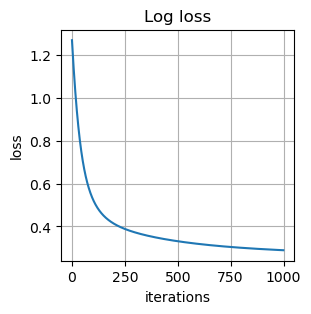

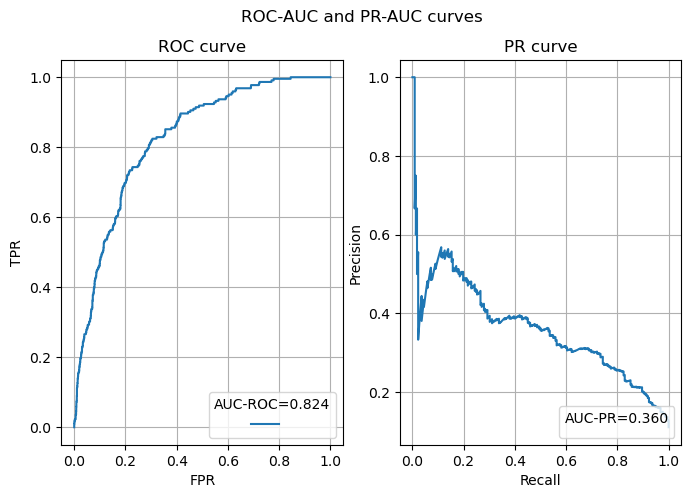

In [14]:
columns_to_create = None
columns_to_drop = ["choose"]
columns_to_scale = ["age", "years_of_experience", "lesson_price", "mean_exam_points", "qualification"]
# modify_cat = "qualification"

pipline = Processing(
    df_train,
    columns_to_scale = columns_to_scale,
    columns_to_drop = columns_to_drop,
    # modify_cat = modify_cat,
    columns_to_create = columns_to_create
)

valid_predictions, valid_proba, train_predictions, train_proba, model, y_train, y_valid = pipline.start_process()

evaluator = EvaluateModel(y_pred=valid_predictions, y_pred_proba=valid_proba, y=y_valid)
evaluator.show_errors(model.errors)
evaluator.evaluation(show_charts=True)

### Error and weight analysis

In [376]:
feature_weights = pd.DataFrame(
    {
        "feature": column_names,
        "weight": model.weights
    },
    columns=["feature", "weight"]
)
feature_weights

,feature,weight
0,W0,-2.427588
1,age,0.046872
2,years_of_experience,0.123734
3,lesson_price,-0.925255
4,qualification,0.229739
5,physics,0.323814
6,chemistry,0.823153
7,biology,0.480834
8,english,-0.398826
9,geography,0.438127


In [617]:
evaluator.confusion_matrix

array([[   3,    1],
       [ 219, 1777]])

#### Baseline model

The strongest positive: 0.823153 (chemistry) and 0.675588 (mean_exam_points) are most likely the most important signs

The strongest negative: -0.925255 (lesson_price)

**Outcomes**

The fiction feature weight is 2.427588. Taking into account that we have disbalance in target feature it has to be normal for this case, because we have a lot of objects belong to 0 class and small number of 1 class objects, therefore model has decided display it on fiction feature. If all features but fiction are equal to 0 chanse for tutor to be chosen is quite small.

chance for tutor to be chosen is getting lower with lesson price growth

In [377]:
print(f"Baseline recall is {np.round(evaluator.recall, 3)}, baseline precision is {np.round(evaluator.precision, 3)}. "\
"The model is good at prediction 1 class objects but the main problem, is the model makes it too rarly. It prefers to choose 0 class\n")

print(f"Baseline fpr is {np.round(evaluator.fpr, 3)}, baseline tpr is {np.round(evaluator.tpr, 3)}. "\
"This metrix have proved outcomes made, using information about recall and precision. The model is tought to predict 0 class very well, but almost "\
"never predicts 1 class\n")

print(f"Baseline ROC-AUC is {np.round(evaluator.auc_roc_score, 3)}, wich is quite good for classifier, but regarding the fact that target "\
f"feature have big disbalance we shold use PR_AUC - {np.round(evaluator.auc_pr_score, 3)}")

Baseline recall is 0.014, baseline precision is 0.75. The model is good at prediction 1 class objects but the main problem, is the model makes it too rarly. It prefers to choose 0 class

Baseline fpr is 0.001, baseline tpr is 0.014. This metrix have proved outcomes made, using information about recall and precision. The model is tought to predict 0 class very well, but almost never predicts 1 class

Baseline ROC-AUC is 0.834, wich is quite good for classifier, but regarding the fact that target feature have big disbalance we shold use PR_AUC - 0.376


Now we should deal with feature engineering and improve model (exceed baseline model metrix)

### Feature engineering

In [378]:
evaluator.confusion_matrix

array([[   3,    1],
       [ 219, 1777]])

So we have almost perfect prediction for 0 class with only 1 mistake and 3 correctly predicted 1 class out of 222. Let's start here, search the difference

In [379]:
fn_idx = np.where((y_valid == 1) & (valid_predictions == 0))[0]
tn_idx = np.where((y_valid == 0) & (valid_predictions == 0))[0]

In [380]:
df_class1 = X_valid.iloc[fn_idx]
df_class0 = X_valid.iloc[tn_idx]
df_class1.head()

,age,years_of_experience,lesson_price,qualification,physics,chemistry,biology,english,geography,history,mean_exam_points
7043,52.0,1.0,1100.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,67.0
5819,50.0,0.0,1300.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,63.0
5644,42.0,3.0,1650.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,70.0
9010,53.0,2.0,1200.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,77.0
2683,33.0,2.0,1100.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,62.0


In [381]:
df_class0["price_to_experience"] = df_class0["lesson_price"] / (df_class0["years_of_experience"] + 1)
df_class1["price_to_experience"] = df_class1["lesson_price"] / (df_class1["years_of_experience"] + 1)

C:\Users\ilyas\AppData\Local\Temp\ipykernel_2100\854406785.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_class0["price_to_experience"] = df_class0["lesson_price"] / (df_class0["years_of_experience"] + 1)
C:\Users\ilyas\AppData\Local\Temp\ipykernel_2100\854406785.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_class1["price_to_experience"] = df_class1["lesson_price"] / (df_class1["years_of_experience"] + 1)


In [382]:
df_class0.groupby(by="years_of_experience").agg({"mean_exam_points": "median", "lesson_price": "median", "price_to_experience": "mean"})

,mean_exam_points,lesson_price,price_to_experience
years_of_experience,,,
0.0,62.0,1500.0,1594.291339
1.0,60.5,1500.0,797.368421
2.0,61.0,1550.0,551.807910
3.0,62.0,1550.0,432.194245
4.0,68.0,1800.0,394.256410
5.0,72.0,2100.0,347.395833
6.0,75.0,1950.0,304.608295
7.0,61.0,2000.0,246.250000
8.0,84.0,2200.0,244.444444


In [383]:
df_class1.groupby(by="years_of_experience").agg({"mean_exam_points": "median", "lesson_price": "median", "price_to_experience": "mean"})

,mean_exam_points,lesson_price,price_to_experience
years_of_experience,,,
0.0,66.0,1400.0,1540.298507
1.0,73.0,1650.0,851.666667
2.0,66.5,1300.0,488.888889
3.0,62.5,1250.0,340.909091
4.0,64.0,1050.0,249.285714
5.0,82.5,1975.0,293.333333
6.0,83.0,1600.0,226.785714
7.0,58.0,850.0,106.250000


The lesson price chosen tutors was a bit less. The same fact price_to_experience feture displayed. 

In [384]:
all_chosen_count = df_train.loc[df_train["choose"] == 1, "years_of_experience"].value_counts().sum()
all_chosen_count_percent = df_train.loc[df_train["choose"] == 1, "years_of_experience"].value_counts() / all_chosen_count * 100
all_chosen_count_percent

years_of_experience
0.0    26.330027
2.0    18.575293
1.0    16.140667
3.0    15.599639
4.0    12.173129
5.0     5.770965
6.0     3.787196
7.0     1.352570
8.0     0.270514
Name: count, dtype: float64

In [385]:
all_notchosen_count = df_train.loc[df_train["choose"] == 0, "years_of_experience"].value_counts().sum()
all_notchosen_count_percent = df_train.loc[df_train["choose"] == 0, "years_of_experience"].value_counts() / all_notchosen_count * 100
all_notchosen_count_percent

years_of_experience
0.0    27.915870
1.0    18.704308
2.0    17.287144
3.0    15.431335
4.0    11.719717
5.0     5.814869
6.0     2.159487
7.0     0.652345
8.0     0.213699
9.0     0.101226
Name: count, dtype: float64

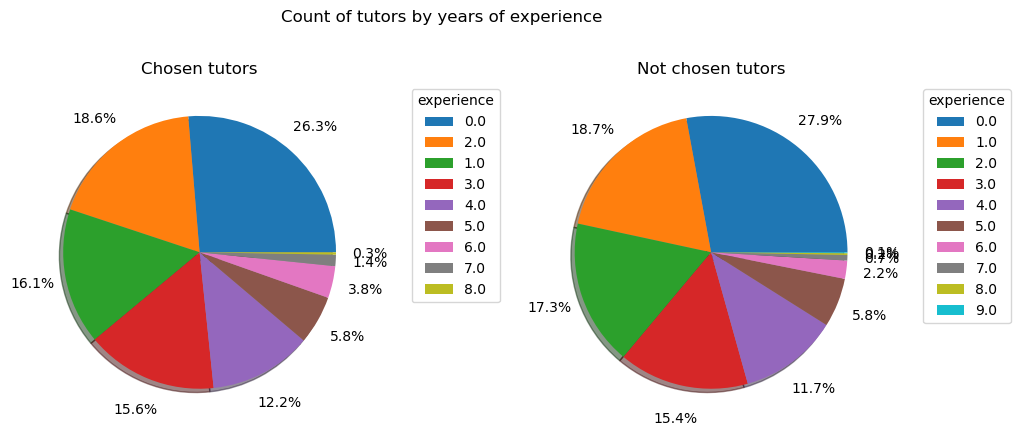

In [386]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 5))

ax1, ax2, = axes.flatten()

fig.suptitle("Count of tutors by years of experience")

ax1.pie(
    x=all_chosen_count_percent.values,
    autopct='%1.1f%%',
    shadow=True,
    pctdistance=1.25,
    labeldistance=.5,
    # labels=all_chosen_count_percent.index
)
ax1.legend(
    title="experience",
    labels=all_chosen_count_percent.index,
    bbox_to_anchor=(0.9, 0, 0.5, 1),
)
ax1.set_title("Chosen tutors")

ax2.pie(
    x=all_notchosen_count_percent.values,
    autopct='%1.1f%%',
    shadow=True,
    pctdistance=1.25,
    labeldistance=.5,
    # labels=all_notchosen_count_percent.index
)
ax2.legend(
    title="experience",
    labels=all_notchosen_count_percent.index,
    bbox_to_anchor=(0.9, 0, 0.5, 1),
)
ax2.set_title("Not chosen tutors")

plt.subplots_adjust(wspace=0.5, hspace=0.3)

plt.show()

Tutors with 0-2 years of experience were the most popular category, next 3-4 and 4+

In [387]:
df_class0["price_score_ratio"] = df_class0["lesson_price"] / df_class0["mean_exam_points"]
df_class1["price_score_ratio"] = df_class1["lesson_price"] / df_class1["mean_exam_points"]

C:\Users\ilyas\AppData\Local\Temp\ipykernel_2100\2461220292.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_class0["price_score_ratio"] = df_class0["lesson_price"] / df_class0["mean_exam_points"]
C:\Users\ilyas\AppData\Local\Temp\ipykernel_2100\2461220292.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_class1["price_score_ratio"] = df_class1["lesson_price"] / df_class1["mean_exam_points"]


In [388]:
df_class0.groupby(by="years_of_experience").agg({"price_score_ratio": "mean"})

,price_score_ratio
years_of_experience,
0.0,26.396992
1.0,26.712310
2.0,27.126802
3.0,27.310086
4.0,28.717498
5.0,29.042232
6.0,30.480637
7.0,32.180041
8.0,28.359727


In [389]:
df_class1.groupby(by="years_of_experience").agg({"price_score_ratio": "mean"})

,price_score_ratio
years_of_experience,
0.0,22.731970
1.0,23.687948
2.0,21.111837
3.0,20.846176
4.0,17.832583
5.0,22.480754
6.0,19.953091
7.0,14.655172


The noticeable difference can be seen in new feature "price_score_ratio" for 1 and 0 class. This shows us, that cost of 1 exam point 1 class tutors less than 0 class

Ideas
- The ratio of lesson price to years of experience
- The ratio of lesson price to mean exam points
- Make groups "years of experience"

Target: exceed Baseline ROC-AUC = 0.834, PR-AUC = 0.376

Try 1 - Delete "lesson price and mean exam points", make new feature - price to experience (divide)

results: ROC-AUC = 0.651, PR-AUC = 0.171 (Worse)

Try 2 - Delete "lesson price and mean exam points", make new feature - price to mean exam points (divide)

results: ROC-AUC = 0.837, PR-AUC = 0.390 (A bit better)

Try 3 - Delete "lesson price and mean exam points", make new feature - binning - years_of_experiments

results: ROC-AUC = 0.641, PR-AUC = 0.160 (Worse)

Try 4 - Delete "lesson price and qualification", make new feature - price to experience (divide)

results: ROC-AUC = 0.689, PR-AUC = 0.195 (Worse)

Try 5 - Delete "lesson price and qualification", make new feature - price to mean exam points (divide)

results: ROC-AUC = 0.812, PR-AUC = 0.37 (Worse)

Try 6 - Delete "lesson price and qualification", make new feature - binning - years_of_experiments

results: ROC-AUC = 0.67, PR-AUC = 0.19 (Worse)

Try 7 - Delete "mean exam points and qualification", make new feature - price to experience (divide)

results: ROC-AUC = 0.65, PR-AUC = 0.19 (Worse)

Try 8 - Delete "mean exam points and qualification", make new feature - price to mean exam points (divide)

results: ROC-AUC = 0.79, PR-AUC = 0.33 (Worse)

Try 9 - Delete "mean exam points and qualification", make new feature - binning - years_of_experiments (divide)

results: ROC-AUC = 0.65, PR-AUC = 0.19 (Worse)

Try 10 - Delete "lesson price and mean exam points", make new feature - price to experience (multiply)

results: ROC-AUC = 0.71, PR-AUC = 0.23 (Worse)

Try 11 - Delete "lesson price and qualification", make new feature - price to experience (multiply)

results: ROC-AUC = 0.77, PR-AUC = 0.29 (Worse)

Try 12 - Delete "mean_exam_points and qualification", make new feature - price to experience (multiply)

results: ROC-AUC = 0.66, PR-AUC = 0.2 (Worse)

Try 13 - Delete "lesson price and mean exam points", make new feature - price to qualification and mean exam points (combo)

results: ROC-AUC = 0.71, PR-AUC = 0.23 (Worse)

Try 14 - Delete "lesson price and qualification", make new feature - price to qualification and mean exam points (combo)

results: ROC-AUC = 0.75, PR-AUC = 0.23 (Worse)

Try 15 - Delete "mean_exam_points and qualification", make new feature - price to qualification and mean exam points (combo)

results: ROC-AUC = 0.81, PR-AUC = 0.33 (Worse)

Try 16 - Delete "lesson price and mean exam points", make new feature - price to qualification and experience (combo)

results: ROC-AUC = 0.64, PR-AUC = 0.132 (Worse)

Try 17 - Delete "lesson price and qualification", make new feature - price to qualification and experience (combo)

results: ROC-AUC = 0.68, PR-AUC = 0.119 (Worse)

Try 18 - Delete "mean_exam_points and qualification", make new feature - price to experience (multiply)

results: ROC-AUC = 0.65, PR-AUC = 0.119 (Worse)

Created |price_score| columns
Deleted |choose, lesson_price, mean_exam_points| columns
Features to scale: |age, years_of_experience, qualification, price_score|
Scaler has been fitted on X_train
X_train and X_valid have been scaled
Added fiction feature to X_train_scaled, X_valid_scaled, now their shape is  (6000, 11) (2000, 11)
Model has been fitted
Min possibility: 1.6842518938451237e-05
Max possibility: 0.9019826388054265
Mean possibility: 0.12017785743664366
Current weights: [-2.64496453  0.04875411  0.03008275  0.63031156  0.12197679 -0.05535908
  0.82670347  0.45101078 -0.43090322  0.42927517 -1.41928885]


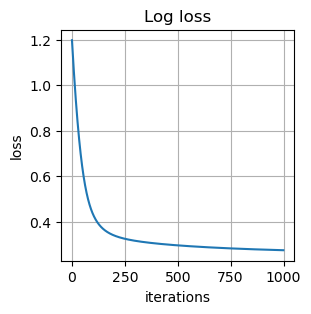

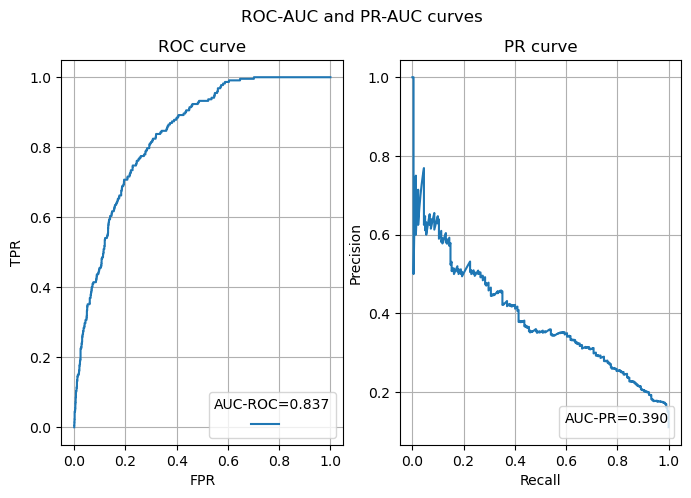

Base metrix:
Precision - 0.6522
Recall - 0.0676
TPR - 0.0676
FPR - 0.0045


In [10]:
columns_to_create = {"price_score": ["lesson_price", "mean_exam_points", "divide"]}
columns_to_drop = ["choose", "lesson_price", "mean_exam_points"]
columns_to_scale = ["age", "years_of_experience", "lesson_price", "mean_exam_points", "qualification"]

pr = Processing(
    df_train,
    columns_to_scale = columns_to_scale,
    columns_to_drop = columns_to_drop,
    columns_to_create = columns_to_create
)

valid_predictions, valid_proba, X_valid, y_valid, model, column_names = pr.start_process()

evaluator = EvaluateModel(y_pred=valid_predictions, y_pred_proba=valid_proba, y=y_valid)
evaluator.show_errors(model.errors)
evaluator.evaluation(show_charts=True)

In [599]:
feature_weights = pd.DataFrame(
    {
        "feature": column_names,
        "weight": model.weights
    },
    columns=["feature", "weight"]
)
feature_weights

,feature,weight
0,W0,-2.743369
1,age,0.050477
2,qualification,0.554213
3,physics,0.610255
4,chemistry,-0.030401
5,biology,-0.049570
6,english,0.965647
7,geography,0.625603
8,history,-0.491526
9,price_score,-1.270237


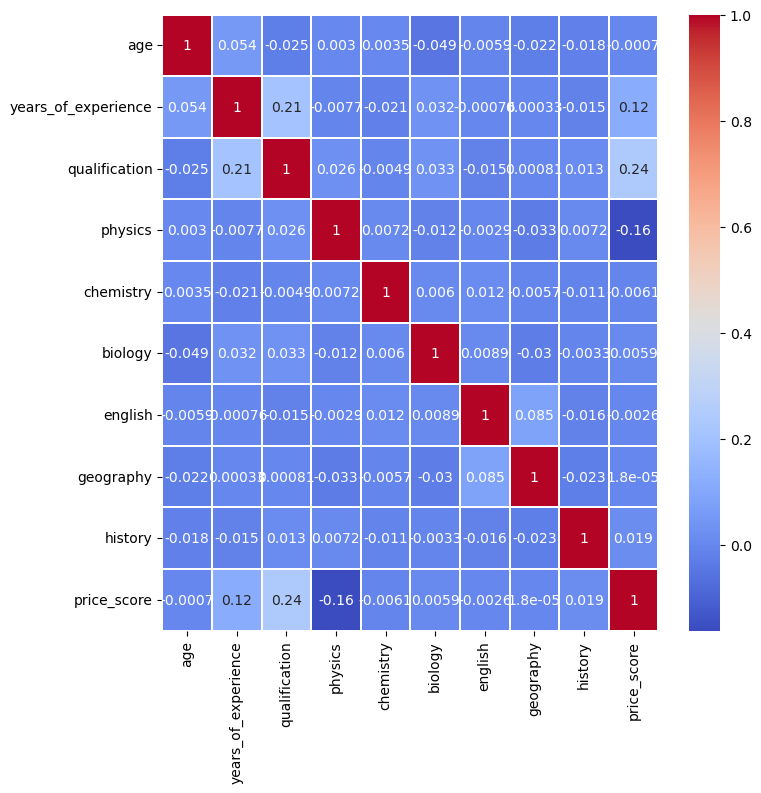

In [420]:
# CORRELATION!
plt.figure(figsize=(8, 8))

matrix_corr = X_valid.corr()

sns.heatmap(data=matrix_corr, annot=True, cmap="coolwarm", linewidths=0.3)

plt.show()

In [283]:
X_valid["choose"] = y_valid.values

In [284]:
X_valid.loc[(X_valid["choose"] == 1), :]

,age,qualification,physics,chemistry,biology,english,geography,history,price_score,experience_group,choose
7043,52.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,16.417910,1,1
5819,50.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,20.634921,1,1
5644,42.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,23.571429,2,1
9010,53.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,15.584416,1,1
2683,33.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,17.741935,1,1
...,...,...,...,...,...,...,...,...,...,...,...
2722,35.0,2.0,0.0,0.0,1.0,0.0,1.0,0.0,25.694444,1,1
4784,53.0,3.0,0.0,1.0,1.0,0.0,0.0,0.0,29.605263,1,1
5948,32.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,16.363636,2,1
3594,41.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,16.666667,2,1


In [402]:
evaluator.confusion_matrix

array([[  31,   22],
       [ 191, 1756]])

In [286]:
fn_to_analize = np.where((valid_predictions != y_valid) & (y_valid == 1))[0]
tn_to_analize = np.where((valid_predictions == y_valid) & (y_valid == 0))[0]
tp_to_analize = np.where((valid_predictions == y_valid) & (y_valid == 1))[0]
df_fn = X_valid.iloc[fn_to_analize]
df_tn = X_valid.iloc[tn_to_analize]
df_tp = X_valid.iloc[tp_to_analize]

In [294]:
df_fn.loc[(df_fn["physics"] == 1) & (df_fn["choose"] == 1)]

,age,qualification,physics,chemistry,biology,english,geography,history,price_score,experience_group,choose
5819,50.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,20.634921,1,1
5644,42.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,23.571429,2,1
8945,45.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,18.902439,2,1
3905,39.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,23.015873,1,1
5891,41.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,18.750000,1,1
...,...,...,...,...,...,...,...,...,...,...,...
2007,43.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,19.014085,1,1
5567,47.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,21.232877,1,1
5601,38.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,20.000000,1,1
5948,32.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,16.363636,2,1


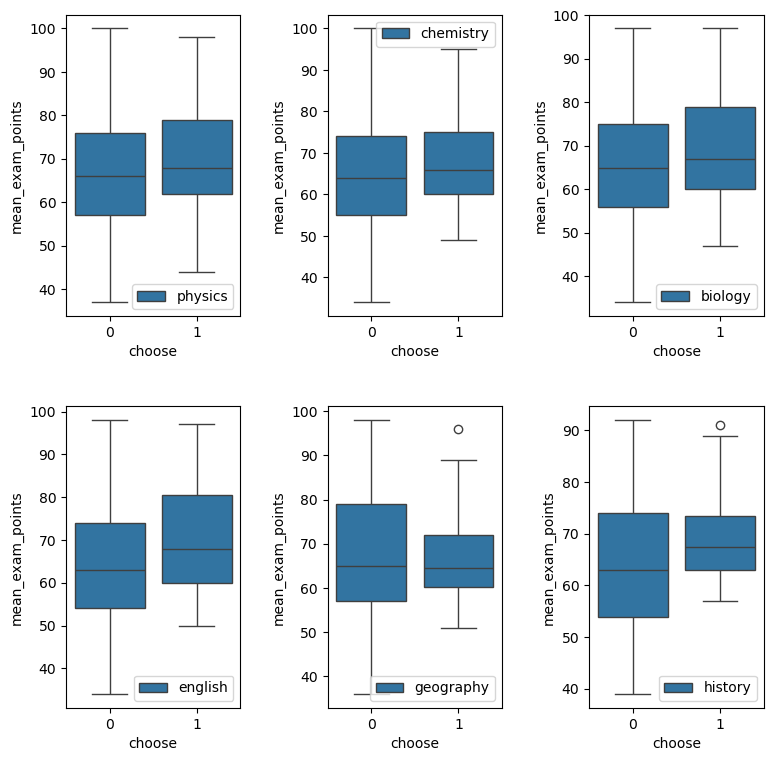

In [454]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(9, 9))
# ax1, ax2, ax3, ax4, ax5 = axes.flatten()
sns.boxplot(
    ax=axes[0][0], 
    data=df_train.loc[df_train["physics"] == 1, ["choose", "mean_exam_points"]],
    x="choose",
    y="mean_exam_points",
    label="physics"
)
sns.boxplot(
    ax=axes[0][1], 
    data=df_train.loc[df_train["chemistry"] == 1, ["choose", "mean_exam_points"]],
    x="choose",
    y="mean_exam_points",
    label="chemistry"
)
sns.boxplot(
    ax=axes[0][2], 
    data=df_train.loc[df_train["biology"] == 1, ["choose", "mean_exam_points"]],
    x="choose",
    y="mean_exam_points",
    label="biology"
)
sns.boxplot(
    ax=axes[1][0], 
    data=df_train.loc[df_train["english"] == 1, ["choose", "mean_exam_points"]],
    x="choose",
    y="mean_exam_points",
    label="english"
)
sns.boxplot(
    ax=axes[1][1], 
    data=df_train.loc[df_train["geography"] == 1, ["choose", "mean_exam_points"]],
    x="choose",
    y="mean_exam_points",
    label="geography"
)
sns.boxplot(
    ax=axes[1][2], 
    data=df_train.loc[df_train["history"] == 1, ["choose", "mean_exam_points"]],
    x="choose",
    y="mean_exam_points",
    label="history"
)

plt.subplots_adjust(wspace=0.5, hspace=0.3)

plt.show()

In [550]:
def show_subject_tutor_distribution_by_experience_and_qualification(df, subjects, qualification):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
    fig.suptitle(f"Tutors of {qualification} qualification who teach subjects by years of experience")
    
    for idx, subject in enumerate(subjects):
        ax = axes[idx // 3, idx % 3]
        
        subject_df = df[(df["qualification"] == qualification) & (df[subject] == 1)]
        
        all_years = sorted(subject_df["years_of_experience"].unique())
        
        years_0 = []
        scores_0 = []
        years_1 = []
        scores_1 = []
        
        for year in all_years:
            data_0 = subject_df[(subject_df["years_of_experience"] == year) & (subject_df["choose"] == 0)]
            if not data_0.empty:
                years_0.append(year)
                scores_0.append(data_0["mean_exam_points"].mean())
            else:
                years_0.append(year)
                scores_0.append(0)
            
            data_1 = subject_df[(subject_df["years_of_experience"] == year) & (subject_df["choose"] == 1)]
            if not data_1.empty:
                years_1.append(year)
                scores_1.append(data_1["mean_exam_points"].mean())
            else:
                years_1.append(year)
                scores_1.append(0)
        
        x = np.arange(len(all_years))
        width = 0.35
        
        ax.bar(x - width/2, scores_0, width, label="Not chosen", alpha=0.7)
        ax.bar(x + width/2, scores_1, width, label="Chosen", alpha=0.7)
        
        ax.set_xlabel("Years of experience")
        ax.set_ylabel("Mean exam points")
        ax.set_title(f"{subject}")
        ax.set_xticks(x)
        ax.set_xticklabels(all_years)
        ax.legend()
        
    plt.tight_layout()
    plt.show()

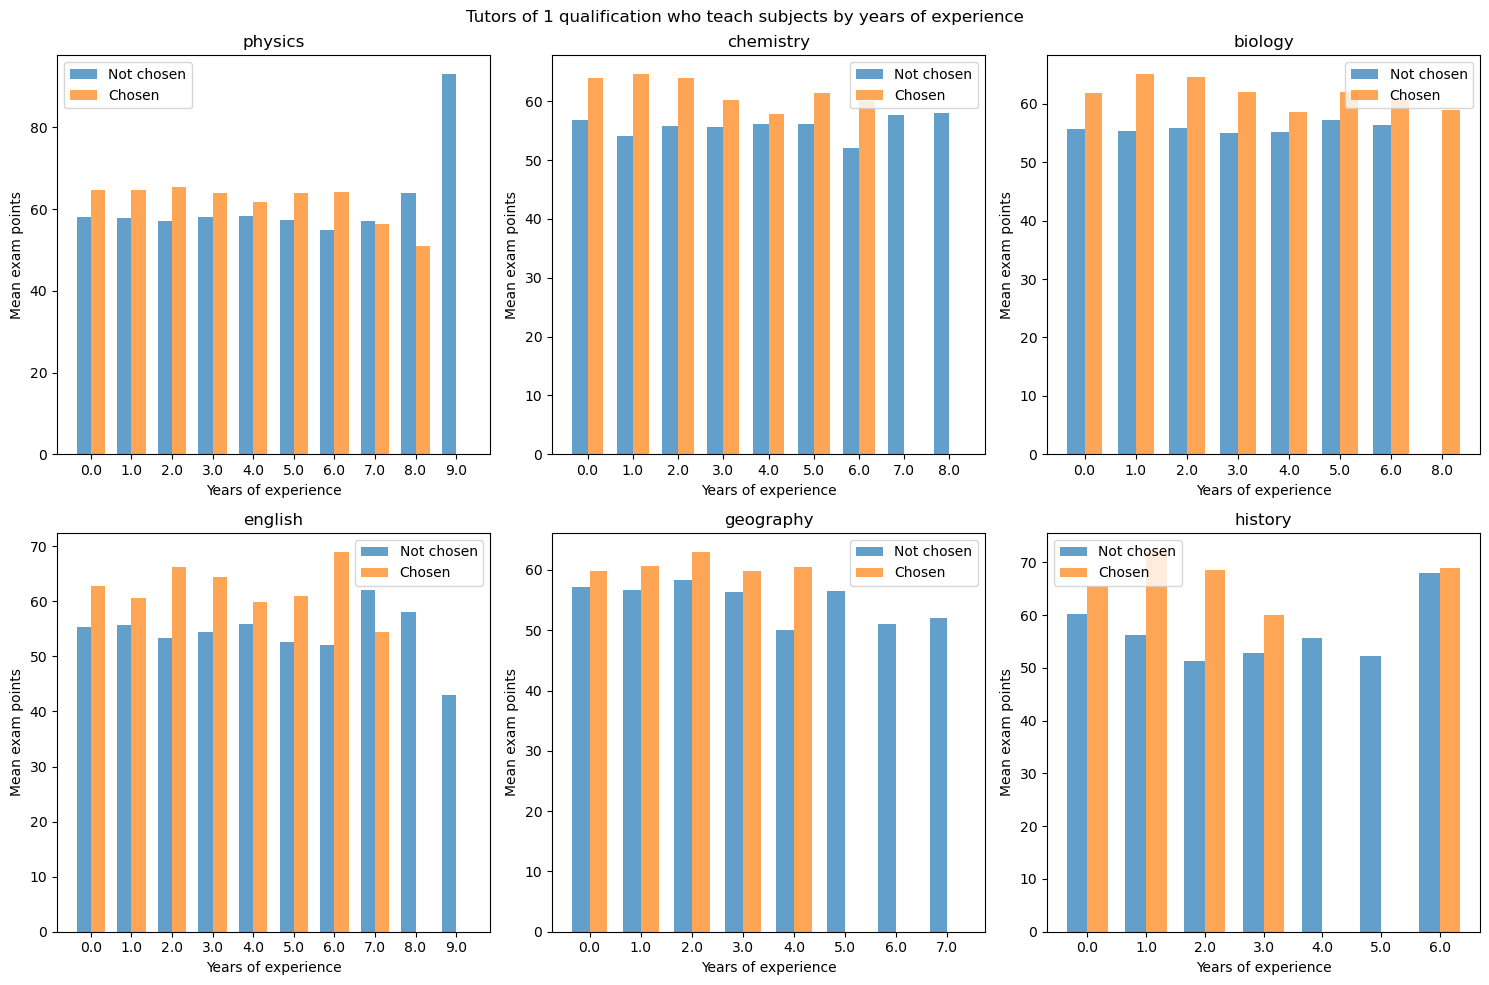

In [555]:
show_subject_tutor_distribution_by_experience_and_qualification(
    df_train, 
    ["physics", "chemistry", "biology", "english", "geography", "history"],
    1
)

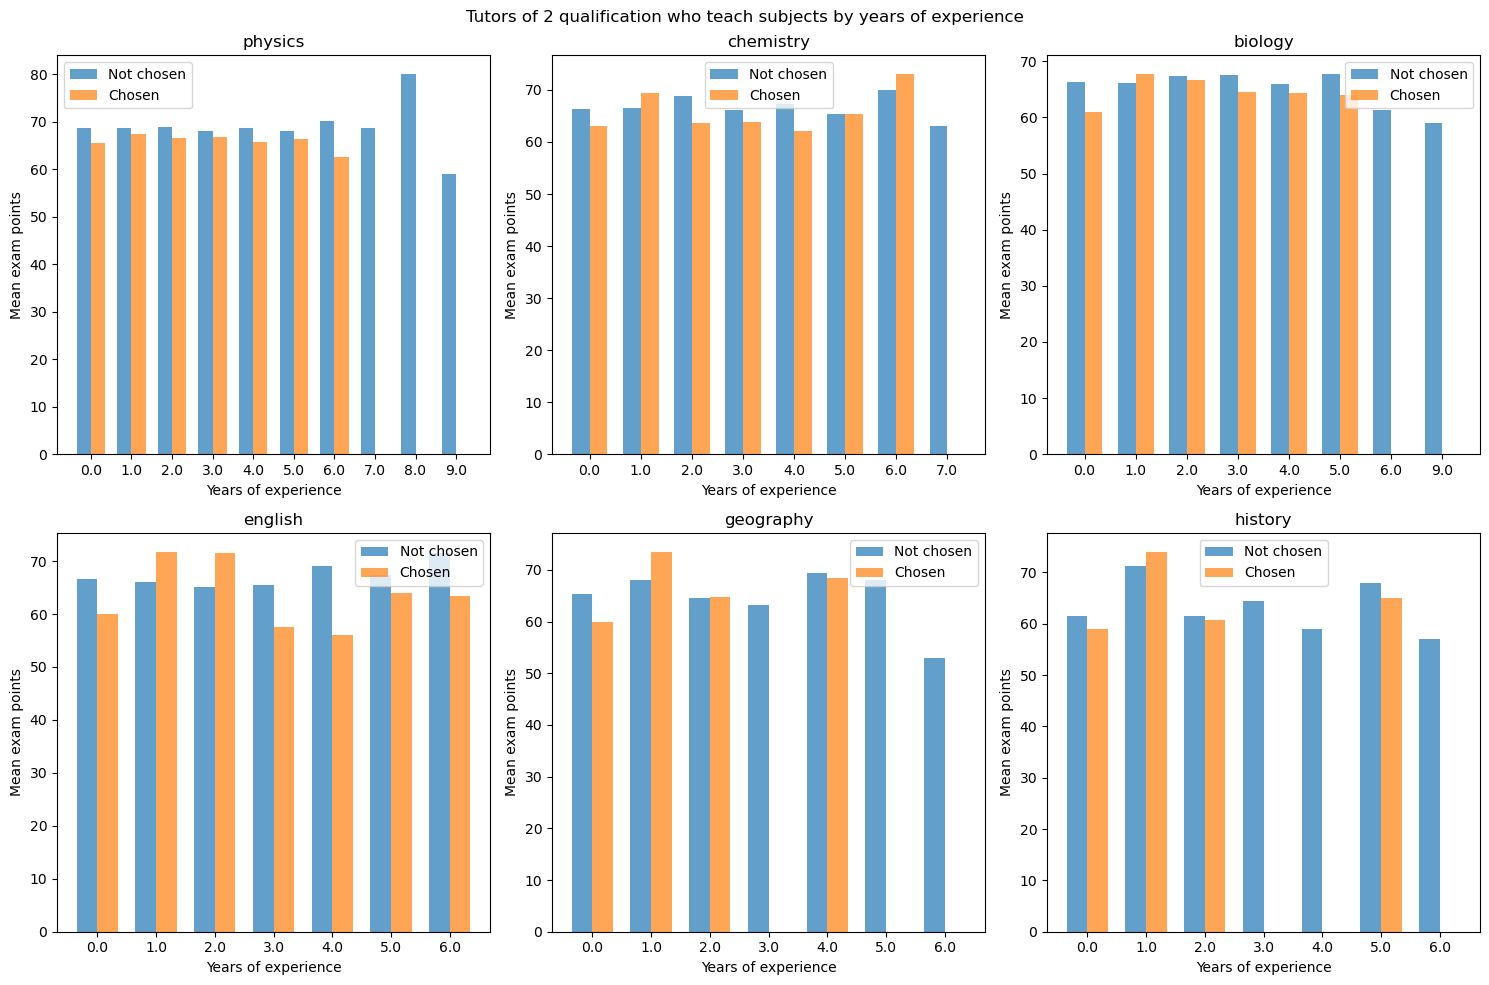

In [552]:
show_subject_tutor_distribution_by_experience_and_qualification(
    df_train, 
    ["physics", "chemistry", "biology", "english", "geography", "history"],
    2
)

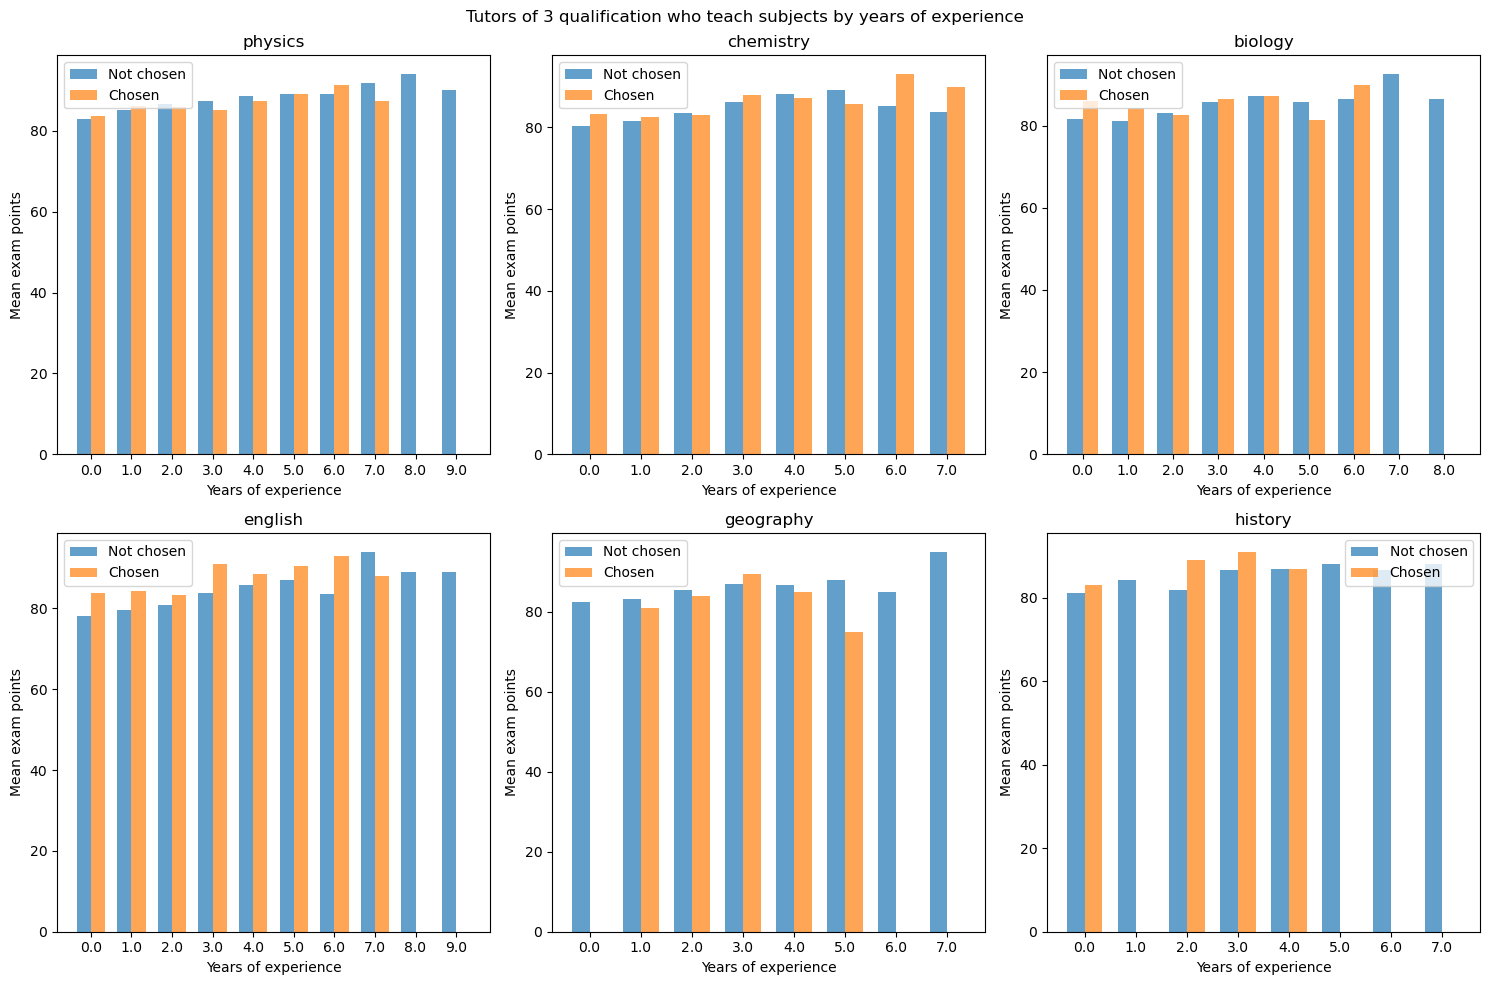

In [553]:
show_subject_tutor_distribution_by_experience_and_qualification(
    df_train, 
    ["physics", "chemistry", "biology", "english", "geography", "history"],
    3
)

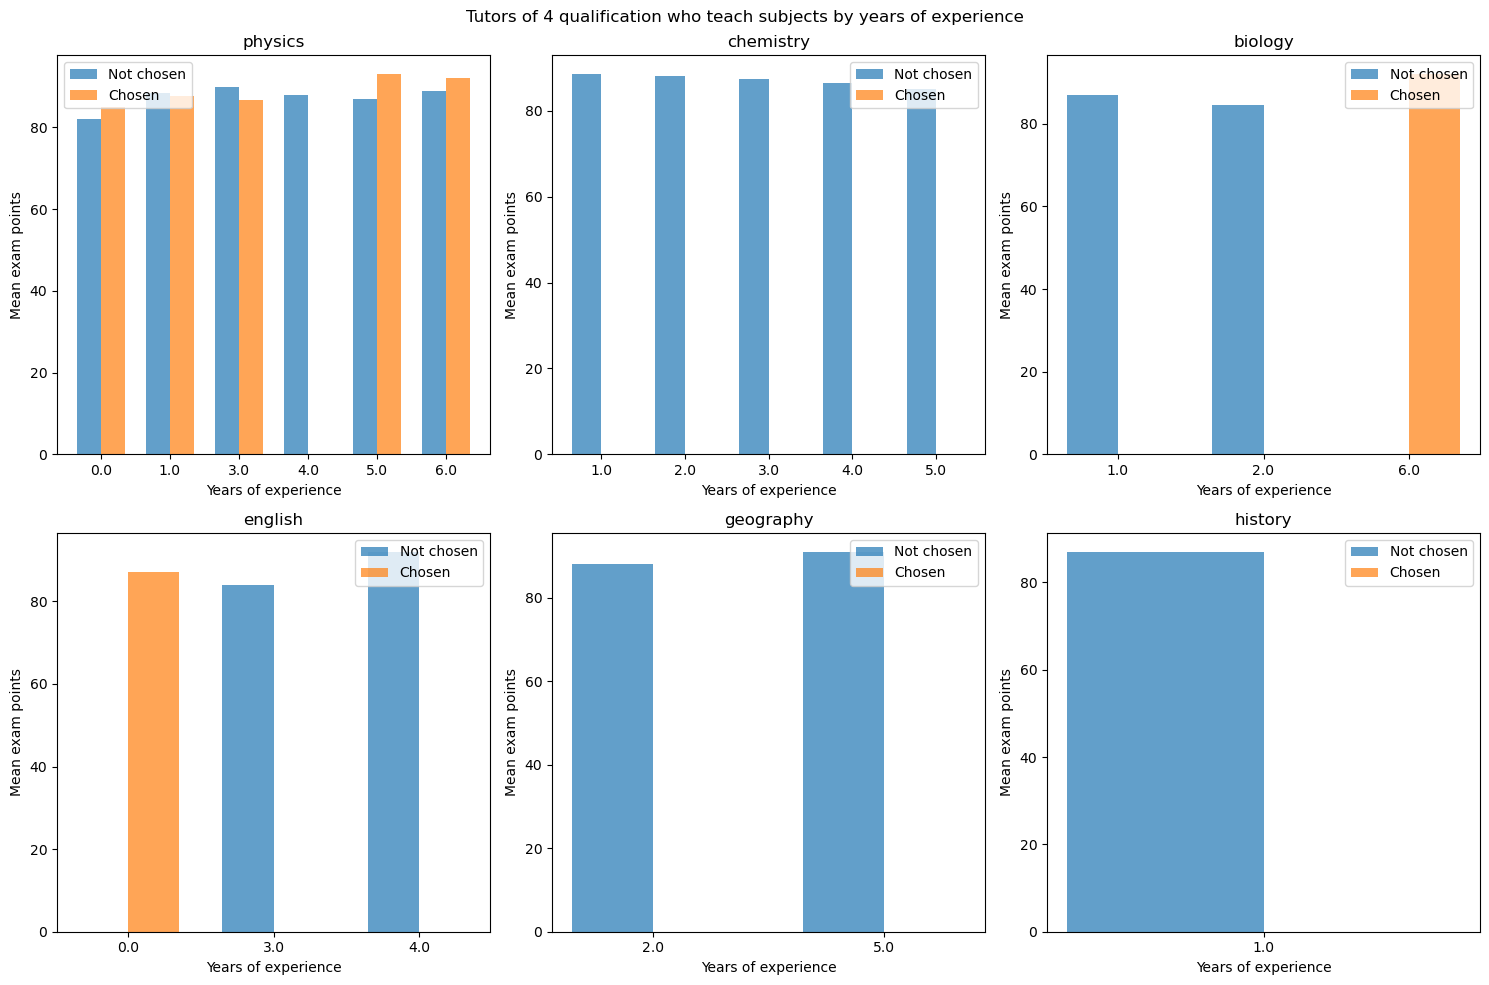

In [554]:
show_subject_tutor_distribution_by_experience_and_qualification(
    df_train, 
    ["physics", "chemistry", "biology", "english", "geography", "history"],
    4
)

According the charts above the next information can be seen:
- 1 qualification. This is for junior tutors. Maybe here people are trying to choose tutor based on mean exam points. Case the chosen tutors of 1 qualification have more exam points
- 2 qualification. Here the trend turn the tide, the chosen tutors have less exam points. This can be connected with the impact of different features.
- 3 qualification. Different results for mean exam points. I inclinde to think, that here people prefer to choose the tutors more carefully, comparing other effects.
- 4 qualification. Little information could be seen here. Maybe it's connected with the fact, that tutors of 4 qualification teach only one subject

### Trying new features

Current best metrix: ROC-AUC = 0.837, PR-AUC = 0.390

Try 1 - Delete "lesson price and mean exam points", make new feature - difference between mean_exam points (in certain qualification) and mean mean_exam in this group (difference)

results: ROC-AUC = 0.836, PR-AUC = 0.391 (A bit better)

Try 2 - Delete "lesson price, mean exam points and years of experience" (delete)

results: ROC-AUC = 0.843, PR-AUC = 0.404 (Better)

Try 3 - Delete "lesson price and mean exam points and years of experience", make new feature - difference between mean_exam points (in certain qualification and year of experience) and mean mean_exam in this group (difference)

results: ROC-AUC = 0.844, PR-AUC = 0.404 (Better, but not cause new feature)

Try 4 - Delete "lesson price and mean exam points", make new feature - binning age

results: ROC-AUC = 0.836, PR-AUC = 0.396 (A bit better)

Try 5 - Delete "lesson price and mean exam points, age", make new feature - binning age

results: ROC-AUC = 0.8, PR-AUC = 0.329 (Worse, but 1 class predicted better)

Try 6 - Delete "lesson price and mean exam points, age, years of experience", make new feature - binning age, years of experience 

results: ROC-AUC = 0.8, PR-AUC = 0.329 (Worse, but 1 class predicted better)

WORK great together:

price_score, effective_index ROC-AUC = 0.846, PR-AUC = 0.419
price_score, effective_index, age_group, max_profitable ROC-AUC = 0.857, PR-AUC = 0.415 del:("choose", "lesson_price", "mean_exam_points", "qualification", "age")
price_score, effective_index, age_group ROC-AUC = 0.858, PR-AUC = 0.420, del:("choose", "lesson_price", "mean_exam_points", "qualification", "age")

Current weights: [-1.64886468  0.00997895  0.53301583  0.89924647 -0.00302567 -0.20087666
  1.30432575  0.63600056 -1.19537717  0.68056364 -0.61527474 -1.23765398
 -1.32081084 -1.60416456 -1.69305314]
Current weights: [-1.64886468  0.00997895  0.53301583  0.89924647 -0.00302567 -0.20087666
  1.30432575  0.63600056 -1.19537717  0.68056364 -0.61527474 -1.23765398
 -1.32081084 -1.60416456 -1.69305314]


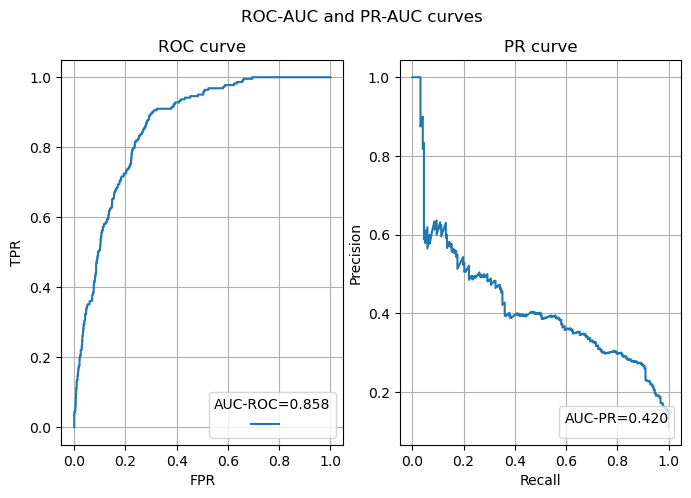

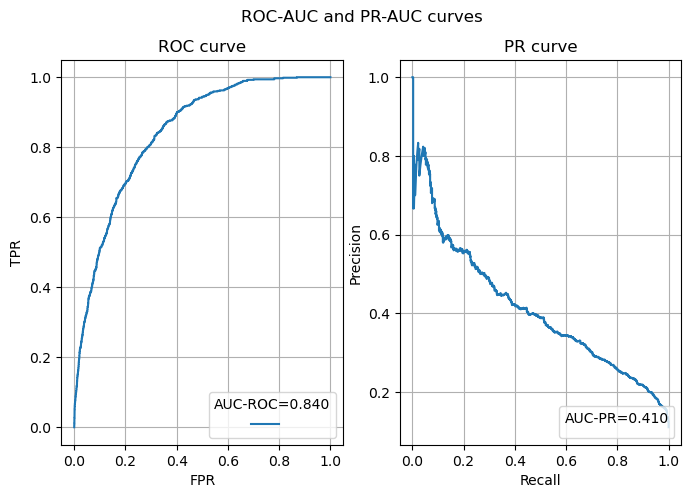

In [264]:
columns_to_create = {
    "price_score": ["lesson_price", "mean_exam_points", "divide"],
    # "price_qualif": ["lesson_price", "qualification", "divide"], # Strange, but maybe,
    "effective_index": [["qualification", "mean_exam_points"], "lesson_price", "combo_multiply"],
    "age_group": ["age", {"bins": [0, 31, 41, 51, 61, float("inf")], "labels": [1, 2, 3, 4, 5]}, "binning"],
    # "max_profitable": ["mean_exam_points", "lesson_price", "bool"],
}
columns_to_drop = ["choose", "lesson_price", "mean_exam_points", "qualification", "age"]
columns_to_scale = ["age", "years_of_experience", "lesson_price", "mean_exam_points", "qualification"]


pr = Processing(
    df_train,
    columns_to_scale = columns_to_scale,
    columns_to_drop = columns_to_drop,
    columns_to_create = columns_to_create,
)

valid_predictions, valid_proba, train_predictions, train_proba, model, y_train, y_valid = pr.start_process()

evaluator_valid = EvaluateModel(y_pred=valid_predictions, y_pred_proba=valid_proba, y=y_valid)
evaluator_valid.evaluation(show_charts=True)
evaluator_train = EvaluateModel(y_pred=train_predictions, y_pred_proba=train_proba, y=y_train)
evaluator_train.evaluation(show_charts=True)

In [265]:
feature_weights = pd.DataFrame(
    {
        "feature": column_names,
        "weight": model.weights
    },
    columns=["feature", "weight"]
)
feature_weights

,feature,weight
0,W0,-1.648865
1,years_of_experience,0.009979
2,physics,0.533016
3,chemistry,0.899246
4,biology,-0.003026
5,english,-0.200877
6,geography,1.304326
7,history,0.636001
8,price_score,-1.195377
9,effective_index,0.680564


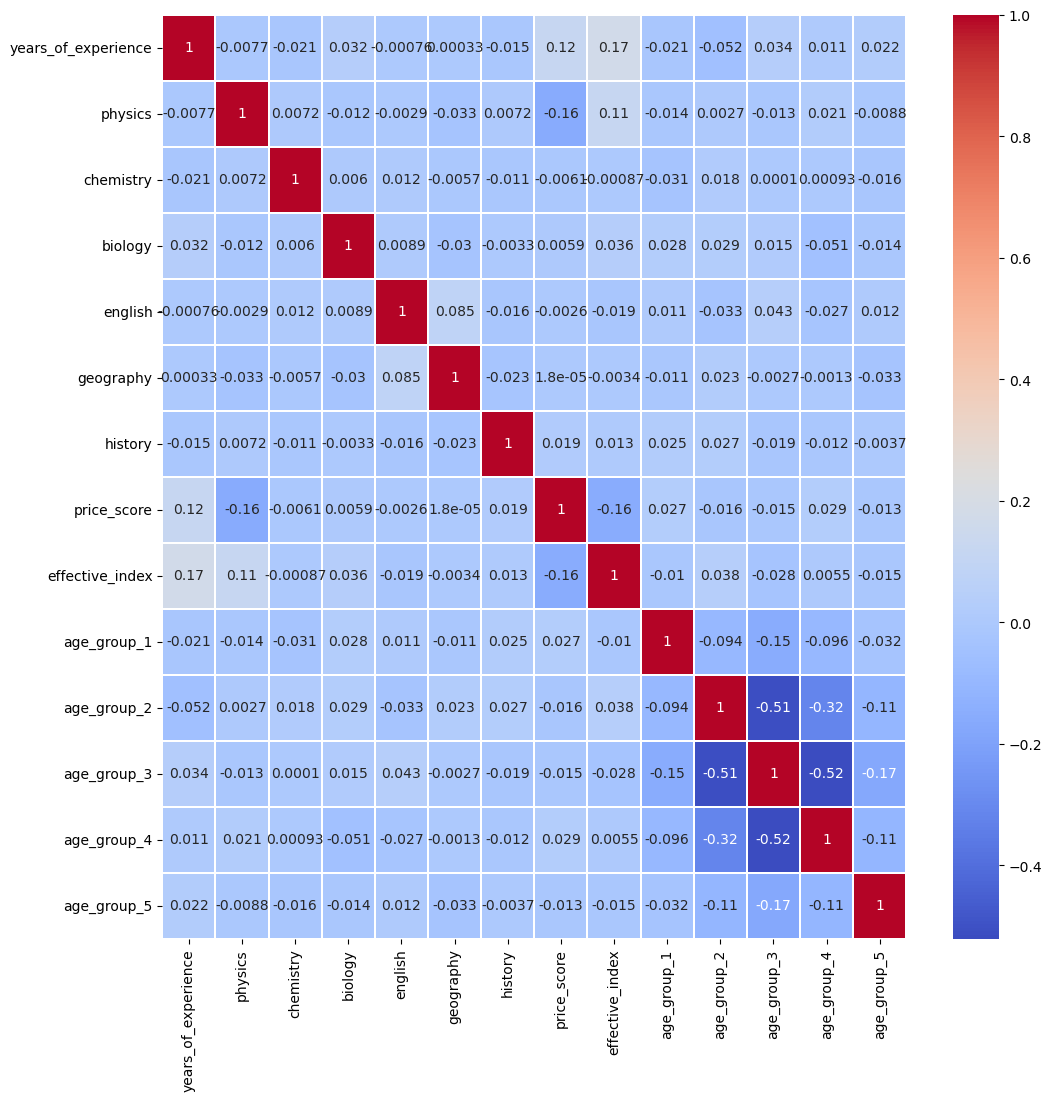

In [266]:
plt.figure(figsize=(12, 12))

matrix_corr = X_valid.corr()

sns.heatmap(data=matrix_corr, annot=True, cmap="coolwarm", linewidths=0.3)

plt.show()

In [226]:
evaluator.confusion_matrix

array([[  28,   17],
       [ 194, 1761]])

### Oversampling and Undersampling

In [250]:
def test_over_and_under_sampling():

    strategies = [
        None, # Base
        "smote",
        "oversample",
        "undersample",
        "adasyn"
    ]
    results = {}

    for strategy in strategies:
        columns_to_create = {
            "price_score": ["lesson_price", "mean_exam_points", "divide"],
            "effective_index": [["qualification", "mean_exam_points"], "lesson_price", "combo_multiply"],
            "age_group": ["age", {"bins": [0, 31, 41, 51, 61, float("inf")], "labels": [1, 2, 3, 4, 5]}, "binning"],
            # "max_profitable": ["mean_exam_points", "lesson_price", "bool"]
        }
        columns_to_drop = ["choose", "lesson_price", "mean_exam_points", "qualification", "age"]
        columns_to_scale = ["age", "years_of_experience", "lesson_price", "mean_exam_points", "qualification"]
        print(f"Strategi - {strategy}")
        pr = Processing(
            df_train,
            columns_to_scale = columns_to_scale,
            columns_to_drop = columns_to_drop,
            columns_to_create = columns_to_create,
            method=strategy
        )
        valid_predictions, valid_proba, train_predictions, train_proba, model, y_train, y_valid = pr.start_process()
        evaluator_valid = EvaluateModel(y_pred=valid_predictions, y_pred_proba=valid_proba, y=y_valid)
        evaluator_valid.evaluation(show_charts=False)
        evaluator_train = EvaluateModel(y_pred=train_predictions, y_pred_proba=train_proba, y=y_train)
        evaluator_train.evaluation(show_charts=False)

        results[strategy] = {
            "Precision Valid": evaluator_valid.precision,
            "Racall Valid": evaluator_valid.recall,
            "Confusion Matrix Valid": evaluator_valid.confusion_matrix,
            "AUC-ROC Valid": evaluator_valid.auc_roc_score,
            "AUC-PR Valid": evaluator_valid.auc_pr_score,
            # Train
            "Precision Train": evaluator_train.precision,
            "Racall Train": evaluator_train.recall,
            "Confusion Matrix Train": evaluator_train.confusion_matrix,
            "AUC-ROC Train": evaluator_train.auc_roc_score,
            "AUC-PR Train": evaluator_train.auc_pr_score,
        }
        print("-"*100)
    return results

In [360]:
strategies = test_over_and_under_sampling()
for strategy in strategies:
    print(strategy)
    print("PRECISION: valid -", strategies[strategy]["Precision Valid"], "train -", strategies[strategy]["Precision Train"])
    print("RECALL: valid -", strategies[strategy]["Racall Valid"], "train -", strategies[strategy]["Racall Train"])
    print("AUC-ROC: valid -", strategies[strategy]["AUC-ROC Valid"], "train -", strategies[strategy]["AUC-ROC Train"])
    print("AUC-PR: valid -", strategies[strategy]["AUC-PR Valid"], "train -", strategies[strategy]["AUC-PR Train"])
    print("-"*100)

Strategi - None
Current weights: [-1.61271873  0.01663938  0.49734106  0.91732899 -0.03813044 -0.21232693
  1.32211402  0.64329227 -1.15790795  0.66517939 -0.60465776 -1.20966862
 -1.2918099  -1.63085551 -1.69782001]
Current weights: [-1.61271873  0.01663938  0.49734106  0.91732899 -0.03813044 -0.21232693
  1.32211402  0.64329227 -1.15790795  0.66517939 -0.60465776 -1.20966862
 -1.2918099  -1.63085551 -1.69782001]
----------------------------------------------------------------------------------------------------
Strategi - smote
Current weights: [ 0.02855504 -0.10283574  1.08442519  1.03272692  0.17713869 -0.12851115
  1.37985046  0.63556782 -1.63165725  1.07669903 -0.62754566 -0.91700471
 -0.8744411  -1.09240233 -1.73896164]
Current weights: [ 0.02855504 -0.10283574  1.08442519  1.03272692  0.17713869 -0.12851115
  1.37985046  0.63556782 -1.63165725  1.07669903 -0.62754566 -0.91700471
 -0.8744411  -1.09240233 -1.73896164]
--------------------------------------------------------------

### Work with overfitting


In [46]:
# strategies = [0.2, 0.3, 0.5, 'auto']
check_random_state = [42, 30, 55, 71, 46]

strategy_results = {}

for strategy in check_random_state:
    columns_to_create = {
        "price_score": ["lesson_price", "mean_exam_points", "divide"],
        "effective_index": [["qualification", "mean_exam_points"], "lesson_price", "combo_multiply"],
        "age_group": ["age", {"bins": [0, 31, 41, 51, 61, float("inf")], "labels": [1, 2, 3, 4, 5]}, "binning"],
        # "max_profitable": ["mean_exam_points", "lesson_price", "bool"]
    }
    columns_to_drop = ["choose", "lesson_price", "mean_exam_points", "qualification", "age"]
    columns_to_scale = ["age", "years_of_experience", "lesson_price", "mean_exam_points", "qualification"]
    pr = Processing(
        df_train,
        columns_to_scale = columns_to_scale,
        columns_to_drop = columns_to_drop,
        columns_to_create = columns_to_create,
        # method="smote",
        method="adasyn", # reg=0.01, lr=0.01, strategy=0.2, k_neighbors=5, n_iter=10000
        # method="undersample",
        # method="oversample",
        strategy=0.2,
        reg=0.01,
        lr=0.01,
        n_iter=10000,
        simple_test=strategy
    )
    
    valid_predictions, valid_proba, train_predictions, train_proba, model, y_train, y_valid = pr.start_process()
    evaluator_valid = EvaluateModel(y_pred=valid_predictions, y_pred_proba=valid_proba, y=y_valid)
    evaluator_valid.evaluation(show_charts=False)
    evaluator_train = EvaluateModel(y_pred=train_predictions, y_pred_proba=train_proba, y=y_train)
    evaluator_train.evaluation(show_charts=False)

    strategy_results[strategy] =  {
        "roc_auc_valid": evaluator_valid.auc_roc_score,
        "pr_auc_valid": evaluator_valid.auc_pr_score,
        "roc_auc_train": evaluator_train.auc_roc_score,
        "pr_auc_train": evaluator_train.auc_pr_score,
    }

for res in strategy_results:
    print(res)
    print(f'ROC-AUC VALID: {np.round(strategy_results[res]["roc_auc_valid"], 4)}| ROC-AUC TRAIN: {np.round(strategy_results[res]["roc_auc_train"], 4)}')
    print(f'PR-AUC VALID: {np.round(strategy_results[res]["pr_auc_valid"], 4)}| PR-AUC TRAIN: {np.round(strategy_results[res]["pr_auc_train"], 4)}')
    print("Difference is", strategy_results[res]["pr_auc_train"] - strategy_results[res]["pr_auc_valid"])
    print("-"*100)

Early stopping on iteration 6700
Current weights: [-1.19892387 -0.00937632  0.30922412  0.29687152  0.07515527 -0.05890796
  0.41463831  0.18108386 -0.85552402  0.56128702 -0.27687641 -0.65468138
 -0.70737692 -0.67456463 -0.61217142]
Current weights: [-1.19892387 -0.00937632  0.30922412  0.29687152  0.07515527 -0.05890796
  0.41463831  0.18108386 -0.85552402  0.56128702 -0.27687641 -0.65468138
 -0.70737692 -0.67456463 -0.61217142]
Current weights: [-1.41831627 -0.03196738  0.23261162  0.21740411  0.10090309  0.03499975
 -0.26625057  0.19234597 -0.84840498  0.57679401  0.08409268 -0.42039531
 -0.52910886 -0.30043009 -0.00903517]
Current weights: [-1.41831627 -0.03196738  0.23261162  0.21740411  0.10090309  0.03499975
 -0.26625057  0.19234597 -0.84840498  0.57679401  0.08409268 -0.42039531
 -0.52910886 -0.30043009 -0.00903517]
Current weights: [-1.41896175 -0.04482945  0.23486475  0.16302336  0.16844014 -0.08877436
 -0.05467468  0.05139103 -0.84398502  0.60072613  0.23922152 -0.42443534


I have tried different combinations for over-sampling and under-sampling. Used regularizations with different reg and count of iterations with eta.

Best option for this ocations - is Adasyn, sampling_strategy=0.2, reg=0.01, eta=0.01.

Next, I checked random state parameter in order to check the model was not lucky with data selection and metrix AUC-PR was got not because of overfitting.

### Final fitting and selection threshold

In [47]:
strategies = [42, 30, 55, 71, 46]
strategy_results = {}
for strategy in strategies:
    columns_to_create = {
        "price_score": ["lesson_price", "mean_exam_points", "divide"],
        "effective_index": [["qualification", "mean_exam_points"], "lesson_price", "combo_multiply"],
        "age_group": ["age", {"bins": [0, 31, 41, 51, 61, float("inf")], "labels": [1, 2, 3, 4, 5]}, "binning"],
    }
    columns_to_drop = ["choose", "lesson_price", "mean_exam_points", "qualification", "age"]
    columns_to_scale = ["age", "years_of_experience", "lesson_price", "mean_exam_points", "qualification"]
    pipeline = Pipeline(
        df_train,
        columns_to_scale = columns_to_scale,
        columns_to_drop = columns_to_drop,
        columns_to_create = columns_to_create,
        method="adasyn",
        strategy=0.2,
        reg=0.01,
        lr=0.01,
        n_iter=10000,
        simple_test=strategy
    )
    
    valid_predictions, valid_proba, train_predictions, train_proba, model, y_train, y_valid, column_names = pipeline.start_process()
    evaluator_valid = EvaluateModel(y_pred=valid_predictions, y_pred_proba=valid_proba, y=y_valid)
    evaluator_valid.evaluation(show_charts=False)
    evaluator_train = EvaluateModel(y_pred=train_predictions, y_pred_proba=train_proba, y=y_train)
    evaluator_train.evaluation(show_charts=False)

    strategy_results[strategy] =  {
        "roc_auc_valid": evaluator_valid.auc_roc_score,
        "pr_auc_valid": evaluator_valid.auc_pr_score,
        "roc_auc_train": evaluator_train.auc_roc_score,
        "pr_auc_train": evaluator_train.auc_pr_score,
        "threshold": model.threshold,
        "F1": model.f1
    }
for res in strategy_results:
    print(res)
    print(f'ROC-AUC VALID: {np.round(strategy_results[res]["roc_auc_valid"], 4)}| ROC-AUC TRAIN: {np.round(strategy_results[res]["roc_auc_train"], 4)}')
    print(f'PR-AUC VALID: {np.round(strategy_results[res]["pr_auc_valid"], 4)}| PR-AUC TRAIN: {np.round(strategy_results[res]["pr_auc_train"], 4)}')
    print("Difference is", strategy_results[res]["pr_auc_train"] - strategy_results[res]["pr_auc_valid"])
    print(f"threshold_check - {strategy_results[res]["threshold"]}")
    print(f"F1  - {strategy_results[res]["F1"]}")
    print("-"*100)

Current weights: [-1.29342124 -0.03465019  0.30604912  0.22409547  0.11219437 -0.06490569
  0.20589924  0.06784274 -0.84923923  0.58217441 -0.2332278  -0.54466361
 -0.64425485 -0.51253097 -0.41795258]
Current weights: [-1.29342124 -0.03465019  0.30604912  0.22409547  0.11219437 -0.06490569
  0.20589924  0.06784274 -0.84923923  0.58217441 -0.2332278  -0.54466361
 -0.64425485 -0.51253097 -0.41795258]
Current weights: [-1.44109480e+00 -6.61828364e-02  2.48047949e-01  2.13545671e-01
  1.06850718e-01  2.53418737e-04 -2.80291742e-01  1.94228550e-01
 -8.50821807e-01  6.02423343e-01  8.61885725e-02 -3.92092158e-01
 -4.90707584e-01 -3.12887148e-01  3.18882932e-02]
Current weights: [-1.44109480e+00 -6.61828364e-02  2.48047949e-01  2.13545671e-01
  1.06850718e-01  2.53418737e-04 -2.80291742e-01  1.94228550e-01
 -8.50821807e-01  6.02423343e-01  8.61885725e-02 -3.92092158e-01
 -4.90707584e-01 -3.12887148e-01  3.18882932e-02]
Current weights: [-1.41363674 -0.05967803  0.23615551  0.19487488  0.13335

As we can see, model is stable. After changing distribution from 60/20/20 to 80/20 model showed nice metrix withour overfitting and underfitting. 

Quite an intresting observation can be seen: some times metrix on Valid data sets were better than on Train data sets. It approved the outcome made previously.

### Final prediction

Min possibility: 0.00015691500998852963
Max possibility: 0.9999974243209654
Mean possibility: 0.19835553090713004
Current weights: [-1.29342124 -0.03465019  0.30604912  0.22409547  0.11219437 -0.06490569
  0.20589924  0.06784274 -0.84923923  0.58217441 -0.2332278  -0.54466361
 -0.64425485 -0.51253097 -0.41795258]
Min possibility: 0.0005287235668991222
Max possibility: 0.9688248605573705
Mean possibility: 0.18932964300937444
Current weights: [-1.29342124 -0.03465019  0.30604912  0.22409547  0.11219437 -0.06490569
  0.20589924  0.06784274 -0.84923923  0.58217441 -0.2332278  -0.54466361
 -0.64425485 -0.51253097 -0.41795258]


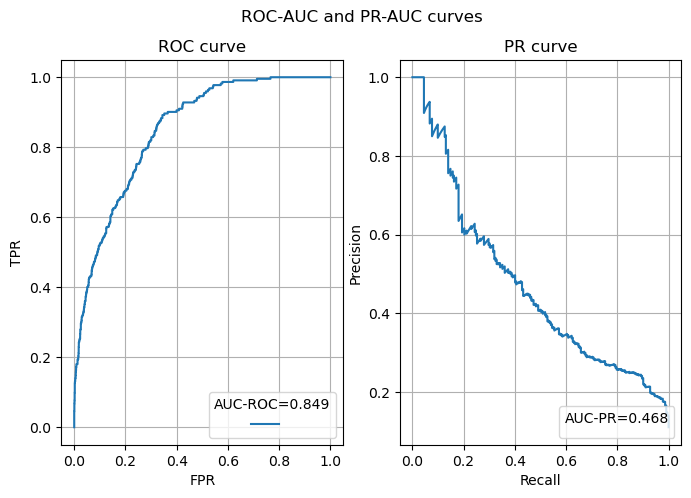

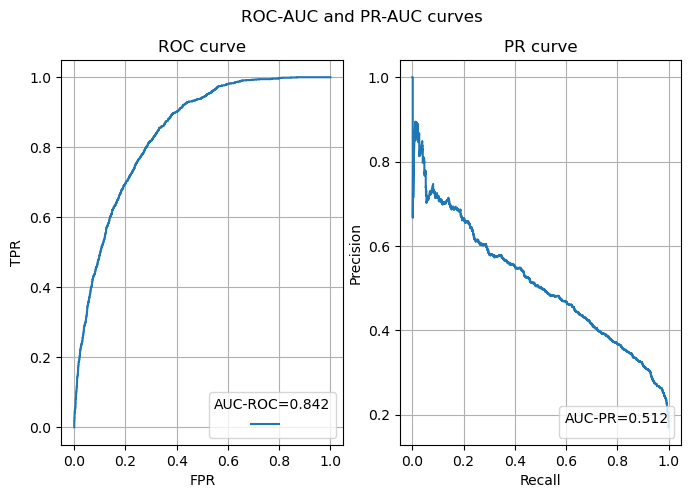

Min possibility: 0.00010047799891198261
Max possibility: 0.9997580679912002
Mean possibility: 0.18579252639002009
Current weights: [-1.29342124 -0.03465019  0.30604912  0.22409547  0.11219437 -0.06490569
  0.20589924  0.06784274 -0.84923923  0.58217441 -0.2332278  -0.54466361
 -0.64425485 -0.51253097 -0.41795258]


In [142]:
columns_to_create = {
    "price_score": ["lesson_price", "mean_exam_points", "divide"],
    "effective_index": [["qualification", "mean_exam_points"], "lesson_price", "combo_multiply"],
    "age_group": ["age", {"bins": [0, 31, 41, 51, 61, float("inf")], "labels": [1, 2, 3, 4, 5]}, "binning"],
}
columns_to_drop = ["lesson_price", "mean_exam_points", "qualification", "age"]
columns_to_scale = ["age", "years_of_experience", "lesson_price", "mean_exam_points", "qualification"]
pipeline = Pipeline()

pipeline = Pipeline()

valid_predictions, valid_proba, train_predictions, train_proba, model, y_train, y_valid, column_names = pipeline.fit_model(
    data=df_train,
    columns_to_scale = columns_to_scale,
    columns_to_drop = columns_to_drop,
    columns_to_create = columns_to_create,
    method="adasyn",
    strategy=0.2,
    reg=0.01,
    lr=0.01,
    n_iter=10000,
    random_state=42
)

evaluator_valid = EvaluateModel(y_pred=valid_predictions, y_pred_proba=valid_proba, y=y_valid)
evaluator_valid.evaluation(show_charts=True)
evaluator_train = EvaluateModel(y_pred=train_predictions, y_pred_proba=train_proba, y=y_train)
evaluator_train.evaluation(show_charts=True)

test_predictions, test_probabilities = pipeline.prepare_and_predict(X=df_test)

In [160]:
result = pd.DataFrame({"Id":df_test["Id"], "choose": test_probabilities}, columns=["Id", "choose"])
result.to_csv("submission.csv", index=False)